## SETUP
**Refer to README file on instructions on how to run the pipeline**

In [1]:
import gc
import os
import math
import time
import random
import pickle
import logging
import warnings
from typing import List, Dict, Set, Optional, Any, Tuple
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse import hstack as sparse_hstack
from tqdm import tqdm

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys
import kagglehub
from google.colab import userdata

import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, StringType

os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

# ------------------------------
# 2. FUNCTION TO DOWNLOAD SINGLE FILE
# ------------------------------
def download_kaggle_file(competition, filename, dest_dir=None):
    """
    Downloads a single file from a Kaggle competition using kagglehub.
    Returns the local file path.
    """
    try:
        # Download the specific file
        path = kagglehub.competition_download(competition, path=filename)
        # path is a directory containing the file, but sometimes it returns the full file path
        # Let's construct the actual file path
        if os.path.isdir(path):
            file_path = os.path.join(path, filename)
        else:
            file_path = path
        print(f"✅ Downloaded {filename} from Kaggle.")
        return file_path
    except Exception as e:
        print(f"❌ Failed to download {filename}: {e}")
        return None

# ------------------------------
# 3. MAIN LOADING LOGIC (Kaggle first, then Drive fallback)
# ------------------------------
def load_hm_data(primary_use_kaggle=True, drive_path='/content/drive/MyDrive/BT4222 Group 04/data/'):
    competition = 'h-and-m-personalized-fashion-recommendations'
    files = ['articles.csv', 'customers.csv', 'transactions_train.csv']
    dataframes = {}

    # Try Kaggle first
    if primary_use_kaggle:
        print("Attempting to download individual files from Kaggle...")
        all_ok = True
        for f in files:
            file_path = download_kaggle_file(competition, f)
            if file_path and os.path.exists(file_path):
                dataframes[f] = pd.read_csv(file_path)
            else:
                all_ok = False
                break
        if all_ok:
            print("✅ All files loaded from Kaggle.")
            return dataframes['articles.csv'], dataframes['customers.csv'], dataframes['transactions_train.csv']

    # Fallback to Drive
    print("Falling back to Google Drive path...")
    try:
        df_articles     = pd.read_csv(f"{drive_path}articles.csv")
        df_customers    = pd.read_csv(f"{drive_path}customers.csv")
        df_transactions = pd.read_csv(f"{drive_path}transactions_train.csv")
        print("✅ Data loaded from Drive.")
        return df_articles, df_customers, df_transactions
    except Exception as e:
        raise RuntimeError(f"Both Kaggle and Drive loading failed.\nDrive error: {e}")

# ------------------------------
# 4. EXECUTION
# ------------------------------
try:
    df_articles, df_customers, df_transactions = load_hm_data(
        primary_use_kaggle=True,
        drive_path='/content/drive/MyDrive/BT4222 Group 04/data/'
    )

    print("\n--- Data loaded successfully ---")
    print("Articles shape:", df_articles.shape)
    print("Customers shape:", df_customers.shape)
    print("Transactions shape:", df_transactions.shape)

    # Optional: show column lists
    print("\nArticles columns:", df_articles.columns.tolist())
    print("Customers columns:", df_customers.columns.tolist())
    print("Transactions columns:", df_transactions.columns.tolist())

except RuntimeError as e:
    print("FATAL:", e)


Attempting to download individual files from Kaggle...
✅ Downloaded articles.csv from Kaggle.
✅ Downloaded customers.csv from Kaggle.
✅ Downloaded transactions_train.csv from Kaggle.
✅ All files loaded from Kaggle.

--- Data loaded successfully ---
Articles shape: (105542, 25)
Customers shape: (1371980, 7)
Transactions shape: (31788324, 5)

Articles columns: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']
Customers columns: ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']
Tra

In [4]:
# Lengths of datasets
print(f"Size of transactions dataset: {len(df_transactions):,}")
print(f"Size of customers dataset: {len(df_customers):,}")
print(f"Size of articles dataset: {len(df_articles):,}")

# Date ranges of transaction dataset
print(f"\nDate of first transaction: {df_transactions['t_dat'].min()}")
print(f"Date of last transaction: {df_transactions['t_dat'].max()}")

# Datatypes of datasets
print(f"\nData types of transactions dataset:")
print(df_transactions.dtypes)

Size of transactions dataset: 31,788,324
Size of customers dataset: 1,371,980
Size of articles dataset: 105,542

Date of first transaction: 2018-09-20
Date of last transaction: 2020-09-22

Data types of transactions dataset:
t_dat                object
customer_id          object
article_id            int64
price               float64
sales_channel_id      int64
dtype: object


# Data Cleaning

First, we map the original customer and article IDs to INT32s
- So IDs are compatible with our models
- Saves memory

In [5]:
print("Mapping user and customer IDs to integers...")

# 1. Get unique IDs from the master tables
unique_customers = df_customers['customer_id'].unique()
unique_articles = df_articles['article_id'].unique()

# 2. Create forward mappings (Original ID -> New Integer 0 to N-1)
customer_to_int = {cust_id: i for i, cust_id in enumerate(unique_customers)}
article_to_int = {art_id: i for i, art_id in enumerate(unique_articles)}

# 3. Create reverse mappings (New Integer -> Original String/Int)
int_to_customer = {i: cust_id for cust_id, i in customer_to_int.items()}
int_to_article = {i: art_id for art_id, i in article_to_int.items()}

# 4. Map the IDs in the original dataframes
df_customers['customer_id'] = df_customers['customer_id'].map(customer_to_int)
df_articles['article_id'] = df_articles['article_id'].map(article_to_int)

df_transactions['customer_id'] = df_transactions['customer_id'].map(customer_to_int)
df_transactions['article_id'] = df_transactions['article_id'].map(article_to_int)

# 5. Downcast new IDs to int32 (by default they are int64)
df_customers['customer_id'] = df_customers['customer_id'].astype('int32')
df_articles['article_id'] = df_articles['article_id'].astype('int32')
df_transactions['customer_id'] = df_transactions['customer_id'].astype('int32')
df_transactions['article_id'] = df_transactions['article_id'].astype('int32')

print("Mapping complete!")
print(f"Customer IDs are now integers from 0 to {len(unique_customers)-1}")
print(f"Article IDs are now integers from 0 to {len(unique_articles)-1}")

Mapping user and customer IDs to integers...
Mapping complete!
Customer IDs are now integers from 0 to 1371979
Article IDs are now integers from 0 to 105541


Clean up the **transactions dataset**

In [6]:
print("Cleaning transactions dataset...")

# 1. Downcast numeric columns to save space
df_transactions['price'] = df_transactions['price'].astype('float32')
df_transactions['sales_channel_id'] = df_transactions['sales_channel_id'].astype('int8') # sales channel either 1 (store) or 2 (online)

# 2. Convert date strings to actual datetime objects
df_transactions['t_dat'] = pd.to_datetime(df_transactions['t_dat'])

# 3. Ensure data is sorted chronologically
df_transactions.sort_values(['t_dat', 'customer_id'], inplace=True)
df_transactions.reset_index(drop=True, inplace=True)

# 4. Check for missing values
print("\nMissing values per column:")
print(df_transactions.isna().sum())

Cleaning transactions dataset...

Missing values per column:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64


Clean up the **customers dataset**

In [7]:
# Check what values these columns take on in the original dataset:
cols_to_check = ['FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age']

for col in cols_to_check:
    print(f"Unique values in {col}: {df_customers[col].unique()}")

print("\nMissing values per column (before cleaning):")
print(df_customers.isna().sum())

Unique values in FN: [nan  1.]
Unique values in Active: [nan  1.]
Unique values in club_member_status: ['ACTIVE' nan 'PRE-CREATE' 'LEFT CLUB']
Unique values in fashion_news_frequency: ['NONE' 'Regularly' nan 'Monthly']
Unique values in age: [49. 25. 24. 54. 52. nan 20. 32. 29. 31. 56. 75. 41. 27. 30. 48. 35. 22.
 40. 38. 45. 68. 55. 19. 60. 44. 21. 26. 28. 53. 33. 17. 23. 51. 18. 34.
 57. 47. 70. 50. 63. 58. 43. 67. 72. 42. 39. 79. 71. 59. 36. 62. 37. 46.
 73. 64. 74. 61. 85. 69. 76. 66. 65. 82. 16. 90. 80. 78. 81. 84. 77. 97.
 89. 83. 98. 88. 86. 87. 93. 91. 99. 96. 94. 92. 95.]

Missing values per column (before cleaning):
customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64


In [8]:
print("Cleaning customers dataset...")

# 1. Clean 'FN' (Fashion News) and 'Active'
# These are currently 1.0 or NaN. We will assume NaN means 0 (False), and cast to int8.
df_customers['FN'] = df_customers['FN'].fillna(0).astype('int8')
df_customers['Active'] = df_customers['Active'].fillna(0).astype('int8')

# 2. Clean 'age'
# We will fill missing ages with -1 and convert to int8
df_customers['age'] = df_customers['age'].fillna(-1).astype('int8')

# 3. Clean 'fashion_news_frequency'
# Fill NaNs with a placeholder, then convert to integers [4 CATEGORIES TOTAL]
df_customers['fashion_news_frequency'] = df_customers['fashion_news_frequency'].fillna('UNKNOWN')
news_codes, news_names = pd.factorize(df_customers['fashion_news_frequency'])
df_customers['fashion_news_frequency'] = news_codes.astype('int8')
news_mapping = {i: name for i, name in enumerate(news_names)}
print("\nFashion News Frequency Mapping:", news_mapping)

# 4. Clean 'club_member_status'
# Fill NaNs with a placeholder, then convert to integers [4 CATEGORIES TOTAL]
df_customers['club_member_status'] = df_customers['club_member_status'].fillna('UNKNOWN')
status_codes, status_names = pd.factorize(df_customers['club_member_status'])
df_customers['club_member_status'] = status_codes.astype('int8')
status_mapping = {i: name for i, name in enumerate(status_names)}
print("Club Member Status Mapping:", status_mapping)

# 5. Clean 'postal_code'
# This is a 64-character string just like the old customer IDs.
# We don't need the string, we just use a unique number to know if users live in the same area.
df_customers['postal_code'] = pd.factorize(df_customers['postal_code'])[0].astype('int32')

print("\nCustomers cleaned successfully!")
print(df_customers.dtypes)

print("\nMissing values per column (after cleaning):")
print(df_customers.isna().sum())

Cleaning customers dataset...

Fashion News Frequency Mapping: {0: 'NONE', 1: 'Regularly', 2: 'UNKNOWN', 3: 'Monthly'}
Club Member Status Mapping: {0: 'ACTIVE', 1: 'UNKNOWN', 2: 'PRE-CREATE', 3: 'LEFT CLUB'}

Customers cleaned successfully!
customer_id               int32
FN                         int8
Active                     int8
club_member_status         int8
fashion_news_frequency     int8
age                        int8
postal_code               int32
dtype: object

Missing values per column (after cleaning):
customer_id               0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    0
age                       0
postal_code               0
dtype: int64


In [9]:
# Determine distributions of categorical variables!

# Count club_member_status
print("--- Club Member Status Counts ---")
counts = df_customers['club_member_status'].value_counts()
for code, count in counts.items():
    label = status_mapping[code]
    print(f"{label} ({code}): {count:,}")

# Count fashion_news_frequency
print("\n--- Fashion News Frequency Counts ---")
counts = df_customers['fashion_news_frequency'].value_counts()
for code, count in counts.items():
    label = news_mapping[code]
    print(f"{label} ({code}): {count:,}")

print("\n--- FN (Fashion News) ---")
print(df_customers['FN'].value_counts())

print("\n--- Active Status ---")
print(df_customers['Active'].value_counts())

print("\n--- Postal Code Stats ---")
top_postal_codes = df_customers['postal_code'].value_counts().head(5)
print("Top 5 Postal Codes by number of customers:")
print(top_postal_codes)


--- Club Member Status Counts ---
ACTIVE (0): 1,272,491
PRE-CREATE (2): 92,960
UNKNOWN (1): 6,062
LEFT CLUB (3): 467

--- Fashion News Frequency Counts ---
NONE (0): 877,711
Regularly (1): 477,416
UNKNOWN (2): 16,011
Monthly (3): 842

--- FN (Fashion News) ---
FN
0    895050
1    476930
Name: count, dtype: int64

--- Active Status ---
Active
0    907576
1    464404
Name: count, dtype: int64

--- Postal Code Stats ---
Top 5 Postal Codes by number of customers:
postal_code
5       120303
8150       261
2065       159
6330       157
5822       156
Name: count, dtype: int64


Clean up the **articles dataset**

In [10]:
print("Cleaning articles dataset...")

# 1. Preparation for BERT
# Create a more detailed text description for each article
text_cols = [
    'prod_name', 'product_type_name', 'product_group_name',
    'graphical_appearance_name', 'colour_group_name',
    'perceived_colour_value_name', 'perceived_colour_master_name',
    'department_name', 'index_name', 'index_group_name',
    'section_name', 'garment_group_name', 'detail_desc'
]
df_articles['combined_text'] = ""
for col in text_cols:
    df_articles['combined_text'] += df_articles[col].fillna('') + " "


# 2. Define the columns that we will keep
# We keep the 'article_id' (already mapped) and all the numeric '_no' or '_code' columns.
# We also keep 'combined_text' for BERT
cols_to_keep = [
    'article_id', 'product_code', 'product_type_no', 'graphical_appearance_no',
    'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id',
    'department_no', 'index_code', 'index_group_no', 'section_no',
    'garment_group_no', 'combined_text'
]
df_articles = df_articles[cols_to_keep].copy()

# 3. Downcase for memory efficiency
df_articles['product_code'] = df_articles['product_code'].astype('int32')
df_articles['product_type_no'] = df_articles['product_type_no'].astype('int16')
df_articles['graphical_appearance_no'] = df_articles['graphical_appearance_no'].astype('int32')
df_articles['colour_group_code'] = df_articles['colour_group_code'].astype('int8')
df_articles['perceived_colour_value_id'] = df_articles['perceived_colour_value_id'].astype('int8')
df_articles['perceived_colour_master_id'] = df_articles['perceived_colour_master_id'].astype('int8')
df_articles['department_no'] = df_articles['department_no'].astype('int16')
df_articles['index_group_no'] = df_articles['index_group_no'].astype('int8')
df_articles['section_no'] = df_articles['section_no'].astype('int8')
df_articles['garment_group_no'] = df_articles['garment_group_no'].astype('int16')

# 4. Convert 'index_code' into number (It's a single letter A-J, not a number)
df_articles['index_code'] = pd.factorize(df_articles['index_code'])[0].astype('int8')

print("Articles cleaned successfully!")
print(df_articles.dtypes)

Cleaning articles dataset...
Articles cleaned successfully!
article_id                     int32
product_code                   int32
product_type_no                int16
graphical_appearance_no        int32
colour_group_code               int8
perceived_colour_value_id       int8
perceived_colour_master_id      int8
department_no                  int16
index_code                      int8
index_group_no                  int8
section_no                      int8
garment_group_no               int16
combined_text                 object
dtype: object


Cleaned datasets:

In [11]:
# Note: FN is if a customer get Fashion News newsletter, Active is if the customer is active for communication, sales channel id, 2 is online and 1 store.

print("Cleaned transactions dataset:")
display(df_transactions.head())
print(df_transactions.dtypes)

Cleaned transactions dataset:


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,2,40179,0.050831,2
1,2018-09-20,2,10520,0.030492,2
2,2018-09-20,7,6387,0.015237,2
3,2018-09-20,7,46304,0.016932,2
4,2018-09-20,7,46305,0.016932,2


t_dat               datetime64[ns]
customer_id                  int32
article_id                   int32
price                      float32
sales_channel_id              int8
dtype: object


In [12]:
print("Cleaned customers dataset:")
display(df_customers.head())
print(df_customers.dtypes)

Cleaned customers dataset:


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,0,0,0,0,0,49,0
1,1,0,0,0,0,25,1
2,2,0,0,0,0,24,2
3,3,0,0,0,0,54,3
4,4,1,1,0,1,52,4


customer_id               int32
FN                         int8
Active                     int8
club_member_status         int8
fashion_news_frequency     int8
age                        int8
postal_code               int32
dtype: object


In [13]:
print("Cleaned articles dataset:")
display(df_articles.head())
print(df_articles.dtypes)

Cleaned articles dataset:


,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_code,index_group_no,section_no,garment_group_no,combined_text
0,0,108775,253,1010016,9,4,5,1676,0,1,16,1002,Strap top Vest top Garment Upper body Solid Bl...
1,1,108775,253,1010016,10,3,9,1676,0,1,16,1002,Strap top Vest top Garment Upper body Solid Wh...
2,2,108775,253,1010017,11,1,9,1676,0,1,16,1002,Strap top (1) Vest top Garment Upper body Stri...
3,3,110065,306,1010016,9,4,5,1339,1,1,61,1017,OP T-shirt (Idro) Bra Underwear Solid Black Da...
4,4,110065,306,1010016,10,3,9,1339,1,1,61,1017,OP T-shirt (Idro) Bra Underwear Solid White Li...


article_id                     int32
product_code                   int32
product_type_no                int16
graphical_appearance_no        int32
colour_group_code               int8
perceived_colour_value_id       int8
perceived_colour_master_id      int8
department_no                  int16
index_code                      int8
index_group_no                  int8
section_no                      int8
garment_group_no               int16
combined_text                 object
dtype: object


# General Time-Based Features (non-leakage)

Since our ranking model will be a neural network, we encode periodic calendar variables using cyclic transformations rather than raw integer values. This is because time variables such as day of week and month are circular in nature: for example, Sunday is close to Monday, and December is close to January, even though their raw numerical values are far apart. To preserve this structure, each periodic feature is represented using sine and cosine transformations. We apply cyclic encoding to day of week, day of month, day of year, week of year, month, and season. The binary is_weekend flag is retained as a standard indicator variable. This representation allows the neural network to better capture recurring temporal and seasonal purchase patterns.

We will implement 7 time-based featuers:
1. `day_of_week` (sin and cos)
2. `day_of_month` (sin and cos)
3. `day_of_year` (sin and cos)
4. `week_of_year` (sin and cos)
5. `month` (sin and cos)
6. `season` (sin and cos)
7. `is_weekend` (a flag which is 0 or 1)

In [14]:
import numpy as np

print("Extracting cyclic time-based features...")

# --------------------------------------------------
# First extract the raw calendar values
# --------------------------------------------------

# 1. day_of_week (0 to 6, where 0 is Monday and 6 is Sunday)
df_transactions['day_of_week'] = df_transactions['t_dat'].dt.dayofweek.astype('int8')

# 2. day_of_month (1 to 31)
df_transactions['day_of_month'] = df_transactions['t_dat'].dt.day.astype('int8')

# 3. day_of_year (1 to 366)
df_transactions['day_of_year'] = df_transactions['t_dat'].dt.dayofyear.astype('int16')

# 4. week_of_year (1 to 53)
df_transactions['week_of_year'] = df_transactions['t_dat'].dt.isocalendar().week.astype('int8')

# 5. month (1 to 12)
df_transactions['month'] = df_transactions['t_dat'].dt.month.astype('int8')

# 6. season (1 to 4)
# Maps: Dec/Jan/Feb -> 1, Mar/Apr/May -> 2, Jun/Jul/Aug -> 3, Sep/Oct/Nov -> 4
def month_to_season(month):
    if month in [12, 1, 2]: return 1   # winter
    elif month in [3, 4, 5]: return 2  # spring
    elif month in [6, 7, 8]: return 3  # summer
    else: return 4                      # autumn

df_transactions['season'] = df_transactions['month'].apply(month_to_season).astype('int8')

# 7. is_weekend (0 or 1)
df_transactions['is_weekend'] = (df_transactions['day_of_week'] >= 5).astype('int8')


display(df_transactions.head())

Extracting cyclic time-based features...


,t_dat,customer_id,article_id,price,sales_channel_id,day_of_week,day_of_month,day_of_year,week_of_year,month,season,is_weekend
0,2018-09-20,2,40179,0.050831,2,3,20,263,38,9,4,0
1,2018-09-20,2,10520,0.030492,2,3,20,263,38,9,4,0
2,2018-09-20,7,6387,0.015237,2,3,20,263,38,9,4,0
3,2018-09-20,7,46304,0.016932,2,3,20,263,38,9,4,0
4,2018-09-20,7,46305,0.016932,2,3,20,263,38,9,4,0


# PIPELINE HELPERS

## Step 1 - Data Split

In [15]:
def split_transactions_temporal(df_transactions, cutoff_date):
    """Split transactions into train (before cutoff) and test (on/after cutoff)."""
    train = df_transactions[df_transactions['t_dat'] < cutoff_date]
    test = df_transactions[df_transactions['t_dat'] >= cutoff_date]
    logger.info(f"Split: train rows={len(train)}, test rows={len(test)}")
    return train, test


## Step 2 - Train Set User Subsampling

In [16]:
def compute_user_tx_stats(df_train, df_users):
    # for each user, counts total tx, per-season tx, active months USING TRAIN TRANSACTIONS ONLY
    # returns df_users_stats with all user features + new calculated transaction-based stats

    # Define max date for recency calculations
    max_date = df_train['t_dat'].max()

    # agg users - from transactions dataframe, count total transactions and date of first and last purchase
    cust_aggs = df_train.groupby('customer_id').agg(
        total_transactions=('article_id', 'count'),
        first_purchase_date=('t_dat', 'min'),
        last_purchase_date=('t_dat', 'max')
    ).reset_index()

    # Calculate active months (number of distinct year-month combinations)
    df_train['year_month'] = df_train['t_dat'].dt.to_period('M')
    active_months = df_train.groupby('customer_id')['year_month'].nunique().reset_index()
    active_months.rename(columns={'year_month': 'active_months'}, inplace=True)

    # Merge active months
    cust_aggs = cust_aggs.merge(active_months, on='customer_id', how='left')

    # Season mapping: 1=winter, 2=spring, 3=summer, 4=autumn
    season_name_map = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'autumn'}
    # Per-season transaction counts (pivot: seasons as columns)
    season_counts = df_train.groupby(['customer_id', 'season']).size().unstack(fill_value=0)
    # Rename columns from season numbers to names
    season_counts.columns = [f'transactions_season_{season_name_map[int(col)]}' for col in season_counts.columns]
    season_counts = season_counts.reset_index()

    # Merge all aggregations
    cust_stats = cust_aggs.merge(season_counts, on='customer_id', how='left')

    # Merge with user metadata (keep all users, fill missing stats with 0)
    df_users_stats = df_users.merge(cust_stats, on='customer_id', how='left')

    # Fill NaN values for users with no transactions
    stat_cols = ['total_transactions', 'active_months'] + \
                [col for col in cust_stats.columns if col.startswith('transactions_season_')]
    for col in stat_cols:
        if col in df_users_stats.columns:
            df_users_stats[col] = df_users_stats[col].fillna(0).astype(int)

    df_users_stats = df_users_stats.drop(columns=['first_purchase_date', 'last_purchase_date'], errors='ignore')

    return df_users_stats

def compute_seasonal_balance_score(df_user_stats):
    """
    Compute seasonal balance score using normalized entropy.
    Users with ≤2 total transactions or <2 seasons with purchases get score 0.

    Parameters
    ----------
    df_user_stats : pd.DataFrame
        Must contain columns 'transactions_season_1' through 'transactions_season_4'
        (or any columns with 'transactions_season_' prefix).

    Returns
    -------
    pd.DataFrame
        Original dataframe with added 'seasonal_balance' column.
    """
    # Identify season columns (assumes they exist)
    season_cols = [col for col in df_user_stats.columns if col.startswith('transactions_season_')]

    if not season_cols:
        raise ValueError("No columns starting with 'transactions_season_' found. "
                         "Ensure per-season transaction counts are present.")

    # Extract season counts as a numpy array for vectorized computation
    season_counts = df_user_stats[season_cols].fillna(0).values  # shape (n_users, 4)
    total_tx = season_counts.sum(axis=1)

    # Pre-allocate balance scores array
    balance_scores = np.zeros(len(df_user_stats), dtype=float)

    # Condition 1: total transactions > 2
    mask_sufficient_tx = total_tx > 2

    # For users with sufficient transactions, count distinct seasons with >0 purchases
    n_seasons_with_purchases = (season_counts > 0).sum(axis=1)
    mask_at_least_two_seasons = n_seasons_with_purchases >= 2

    # Final mask: both conditions met
    valid_mask = mask_sufficient_tx & mask_at_least_two_seasons

    # Compute normalized entropy for valid users
    if valid_mask.any():
        # Subset for valid users
        counts_valid = season_counts[valid_mask]
        total_valid = total_tx[valid_mask].reshape(-1, 1)

        # Proportions (avoid division by zero – total_valid > 0 by mask)
        props = counts_valid / total_valid

        # Compute entropy: -sum(p * log(p)), ignoring zeros (log(0)=0)
        # Use np.where to avoid log(0)
        log_props = np.zeros_like(props)
        nonzero_mask = props > 0
        log_props[nonzero_mask] = np.log(props[nonzero_mask])  # natural log
        entropy = -np.sum(props * log_props, axis=1)

        # Normalize by max entropy (log(4) for 4 seasons)
        max_entropy = np.log(4.0)
        normalized_entropy = entropy / max_entropy

        # Assign to balance_scores
        balance_scores[valid_mask] = normalized_entropy

    # Add column to dataframe
    df_user_stats = df_user_stats.copy()
    df_user_stats['seasonal_balance'] = balance_scores

    return df_user_stats


def compute_bucket_thresholds(df_user_stats: pd.DataFrame,
                              low_percentile: float = 10,
                              high_percentile: float = 80) -> tuple:
    """
    Determine low_cut and high_cut thresholds based on percentiles of total_transactions.

    Parameters
    ----------
    df_user_stats : pd.DataFrame
        Must contain 'total_transactions' column.

    Returns
    -------
    tuple
        (low_cut, high_cut) as integers.
    """
    total_tx = df_user_stats['total_transactions']
    low_cut = int(np.percentile(total_tx, low_percentile))
    high_cut = int(np.percentile(total_tx, high_percentile))

    # Ensure at least a small gap between buckets
    if low_cut >= high_cut:
        low_cut = max(1, low_cut - 1)
        high_cut = low_cut + 2

    return low_cut, high_cut


def assign_user_buckets(df_user_stats: pd.DataFrame, low_cut: int, high_cut: int) -> pd.DataFrame:
    """Assign bucket A (low activity), B (medium), C (high) based on total transactions."""
    total_tx = df_user_stats['total_transactions']
    df_user_stats['bucket'] = 'B'
    df_user_stats.loc[total_tx <= low_cut, 'bucket'] = 'A'
    df_user_stats.loc[total_tx >= high_cut, 'bucket'] = 'C'
    return df_user_stats

def subsample_train_users(df_user_stats,
                          n_users: int,
                          balance_threshold: float,
                          seed: int):
    """
    Subsample training users preserving bucket proportions, reallocating if a bucket lacks eligible users.
    If total eligible users < n_users, use all eligible users and log a warning.
    """
    np.random.seed(seed)

    # Step 1: Compute eligible counts per bucket
    eligible_counts = {}
    eligible_dfs = {}
    for bucket in ['A', 'B', 'C']:
        mask = (df_user_stats['bucket'] == bucket) & (df_user_stats['seasonal_balance'] >= balance_threshold)
        eligible_dfs[bucket] = df_user_stats[mask]
        eligible_counts[bucket] = len(eligible_dfs[bucket])

    total_eligible = sum(eligible_counts.values())

    # If not enough eligible users overall, take all and warn
    if total_eligible < n_users:
        logger.warning(f"Total eligible users ({total_eligible}) is less than requested n_users={n_users}. "
                       f"Returning all {total_eligible} eligible users.")
        sampled_ids = []
        for bucket in ['A', 'B', 'C']:
            sampled_ids.extend(eligible_dfs[bucket]['customer_id'].tolist())
        return sampled_ids

    # Step 2: Initial required quotas based on overall bucket proportions
    bucket_props = df_user_stats['bucket'].value_counts(normalize=True)
    required = {bucket: int(round(prop * n_users)) for bucket, prop in bucket_props.items()}

    # Step 3: Check for shortages and cap quotas
    shortage = 0
    for bucket in ['A', 'B', 'C']:
        if eligible_counts[bucket] < required[bucket]:
            shortage += required[bucket] - eligible_counts[bucket]
            required[bucket] = eligible_counts[bucket]  # cap at available

    # Step 4: Distribute shortage to surplus buckets proportionally
    if shortage > 0:
        # Identify buckets with surplus
        surplus_buckets = {b: eligible_counts[b] - required[b] for b in ['A','B','C'] if eligible_counts[b] > required[b]}
        total_surplus = sum(surplus_buckets.values())

        # Distribute shortage across surplus buckets proportionally
        for bucket, surplus in surplus_buckets.items():
            add = int(round((surplus / total_surplus) * shortage))
            required[bucket] += add
        # Adjust for rounding errors
        total_assigned = sum(required.values())
        if total_assigned < n_users:
            largest_surplus = max(surplus_buckets, key=surplus_buckets.get)
            required[largest_surplus] += (n_users - total_assigned)
        elif total_assigned > n_users:
            # Remove excess from largest surplus bucket
            largest_surplus = max(surplus_buckets, key=surplus_buckets.get)
            required[largest_surplus] -= (total_assigned - n_users)

    # Step 5: Sample from each bucket
    sampled_ids = []
    for bucket in ['A', 'B', 'C']:
        n_req = required[bucket]
        if n_req <= 0:
            continue
        eligible_df = eligible_dfs[bucket]
        if len(eligible_df) >= n_req:
            sampled = eligible_df.sample(n=n_req, random_state=seed)
        else:
            # Fallback (should not happen after reallocation)
            sampled = eligible_df
            logger.warning(f"Bucket {bucket}: insufficient eligible users after reallocation. Taking all {len(eligible_df)}.")
        sampled_ids.extend(sampled['customer_id'].tolist())

    return sampled_ids


def validate_subsample(df_train, df_user_stats, sampled_user_ids):
    """
    Validate the subsample of training users.

    Checks:
    1. Bucket distribution (A/B/C) – each bucket must have at least 5% of sampled users.
    2. Seasonal transaction distribution – entropy of observed season distribution must be
       >= 1.2 (out of max 1.386). Flags if transactions are heavily concentrated in
       fewer than ~3 seasons.
    3. Monthly transaction distribution – entropy of observed month distribution must be
       >= 2.2 (out of max 2.485). Flags if transactions are concentrated in a small
       number of months.

    Entropy interpretation:
        H(p) = -sum(p_i * log(p_i))
        Maximum (perfectly uniform) = log(N) where N is number of categories.
        Lower entropy = more skewed distribution = worse seasonal coverage.
        Thresholds are set as minimum acceptable entropy values.

    Returns
    -------
    dict
        Report with distributions, entropy values, and overall pass/fail status.
    """
    import numpy as np

    sampled_users_set = set(sampled_user_ids)
    df_sampled = df_train[df_train['customer_id'].isin(sampled_users_set)].copy()

    # -----------------------------------------------------------------
    # 1. Bucket distribution — minimum 5% per bucket
    # -----------------------------------------------------------------
    MIN_BUCKET_RATIO = 0.05

    bucket_counts = (
        df_user_stats[df_user_stats['customer_id'].isin(sampled_users_set)]
        ['bucket']
        .value_counts()
    )
    bucket_dist = {k: v / len(sampled_user_ids) for k, v in bucket_counts.items()}
    bucket_ok = all(ratio >= MIN_BUCKET_RATIO for ratio in bucket_dist.values())

    # -----------------------------------------------------------------
    # 2. Seasonal transaction distribution — entropy threshold
    # -----------------------------------------------------------------
    # Max possible entropy for 4 seasons: log(4) = 1.386
    SEASON_ENTROPY_THRESHOLD = 1.1

    df_sampled['season'] = df_sampled['t_dat'].dt.month.map(month_to_season)

    seasonal_counts = df_sampled['season'].value_counts()
    for s in range(1, 5):
        if s not in seasonal_counts.index:
            seasonal_counts[s] = 0
    seasonal_counts = seasonal_counts.sort_index()

    seasonal_probs = seasonal_counts / seasonal_counts.sum()
    # Only include non-zero probabilities to avoid log(0)
    nonzero_seasonal = seasonal_probs[seasonal_probs > 0]
    season_entropy = -np.sum(nonzero_seasonal * np.log(nonzero_seasonal))
    season_ok = season_entropy >= SEASON_ENTROPY_THRESHOLD

    season_name_map = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'autumn'}
    transactions_per_season = {
        season_name_map[s]: int(seasonal_counts[s]) for s in range(1, 5)
    }

    # -----------------------------------------------------------------
    # 3. Monthly transaction distribution — entropy threshold
    # -----------------------------------------------------------------
    # Max possible entropy for 12 months: log(12) = 2.485
    MONTH_ENTROPY_THRESHOLD = 2.0

    df_sampled['month'] = df_sampled['t_dat'].dt.month
    monthly_counts = df_sampled['month'].value_counts()
    for m in range(1, 13):
        if m not in monthly_counts.index:
            monthly_counts[m] = 0
    monthly_counts = monthly_counts.sort_index()

    monthly_probs = monthly_counts / monthly_counts.sum()
    nonzero_monthly = monthly_probs[monthly_probs > 0]
    month_entropy = -np.sum(nonzero_monthly * np.log(nonzero_monthly))
    month_ok = month_entropy >= MONTH_ENTROPY_THRESHOLD

    df_sampled['year_month'] = df_sampled['t_dat'].dt.to_period('M').astype(str)
    transactions_per_month = dict(
        sorted(df_sampled['year_month'].value_counts().to_dict().items())
    )

    # -----------------------------------------------------------------
    # Overall status
    # -----------------------------------------------------------------
    status = 'ok' if (bucket_ok and season_ok and month_ok) else 'failed'

    return {
        'bucket_distribution': bucket_dist,
        'bucket_check_passed': bucket_ok,
        'transactions_per_season': transactions_per_season,
        'season_entropy': round(season_entropy, 4),
        'season_entropy_max': round(np.log(4), 4),
        'season_check_passed': season_ok,
        'transactions_per_month': transactions_per_month,
        'month_entropy': round(month_entropy, 4),
        'month_entropy_max': round(np.log(12), 4),
        'month_check_passed': month_ok,
        'status': status,
    }

## Step 3 - NCF Model Training
Expanding window / walk-forward validation across train year

Each fold expands the training window by one month and validates on the next month.

### Transaction-based Features

We add some more features for each transaction:
1. A very critical piece of information is the age of each transaction. It makes sense that older transaction should be weighted less than more recent transactions as more recent transactions are more representative of the current 'state' of the customer. Thus, we add the feature `transaction_age`.
2. Notice that there are purchases by the same customer with the same date. These potentially represent items that the customer bought in one go. That is, probable that all of these items were in the same 'basket' before being purchased. Do note that as we don't have the exact time of each purchase it is impossible to determine if these items were truly all purchased in one go, however, it is a reasonable assumption that doesn't particularly hurt our model even if violated. Distinguishing between these one-time / bulk purchases may reveal more information about the behaviour of the customer which is why we include `basket_size` in our model.

In [17]:
def engineer_transaction_features(df_train, cutoff_date):
    # 1. Transaction Age
    # We calculate the number of days between the transaction and the latest date in the data.
    # This allows the model to 'decay' the importance of older transactions.

    if isinstance(cutoff_date, str):
        cutoff_date = pd.to_datetime(cutoff_date)

    max_date = cutoff_date
    df_train['transaction_age'] = (max_date - df_train['t_dat']).dt.days.astype('int16')

    # 2. Basket Size
    # We group by customer and date to count how many items were purchased in the same 'session'.
    df_train['basket_size'] = df_train.groupby(['customer_id', 't_dat'])['article_id'].transform('count').astype('int16')

    return df_train

### Article-based Features

We will now add some new features to the `df_articles` dataframe.

Firstly, we store the number of times each article is purchased. This is a direct measure of the popularity of the item. However, how *recently* this item is purchased tells us a lot about how 'hot' the item actually is at the moment. Thus, we develop the following features:
1. `article_total_sales` - How many times the article was purchased in total over all time - captures overall popularity of the item.
2. `article_sales_30d` - How many times the article was purchased in the past 30 days - captures current popularity of the item.
3. `article_sales_7d` - How many times the article was purchased in the past 7 days - captures current popularity of the item.
4. `article_sales_decay_score` – an exponentially decayed sales score that weights recent purchases more heavily than older purchases. This provides a smoother and more time-sensitive measure of current demand than a simple rolling count, since a burst of recent sales should matter more than the same number of sales several weeks ago.

Next, we add a feature to capture how newly introduced an article is:

`days_since_first_sale` – the number of days since the article’s first observed sale in the training data. A small value indicates that the article is relatively new, while a missing or special default value can identify articles with no observed sales history at all. This is especially useful for detecting potential cold-start items.

Next, we store statistics related to the price of each article. These are important features as customers almost certainly have preferences towards items in a certain price range.
1. `article_avg_price` - Average purchase price of the article based on past transactions
2. `article_min_price` - Minimum purchase price of article
3. `article_max_price` - Maximum purchase price of article
4. `article_std_price` - Standard deviation of purchase price, which could indicate how frequently the article goes on sale
5. `last_purchase_price` - Most recent purchase price of article

To capture seasonal demand, we include features that describe the historical seasonal purchasing pattern of each article:

`article_season_affinity_winter`, `article_season_affinity_spring`,
`article_season_affinity_summer`,
`article_season_affinity_autumn`, and
`article_peak_season` – the season in which the article historically records the highest proportion of sales.

Finally, we realised that in real life some articles are generally treated as an 'add-on' item whilst others are treated as the main 'hero' item. For example, you might consider a fancy dress to be a 'hero' item which is more likely to be purchased by itself compared to a sticker which is typically an 'add-on' item (i.e., a sticker is more likely to be purchased with other items). To represent this phenomenon we include the `avg_basket_size` feature - the average size of the 'basket' (as described in the previous section) when this item is purchased.



In [18]:
import numpy as np
import pandas as pd

def month_to_season(month):
    if month in [12, 1, 2]: return 1   # winter
    elif month in [3, 4, 5]: return 2  # spring
    elif month in [6, 7, 8]: return 3  # summer
    else: return 4                      # autumn

def engineer_article_features(df_train_transactions, df_articles, cutoff_date):

  if isinstance(cutoff_date, str):
        cutoff_date = pd.to_datetime(cutoff_date)


  reference_date = cutoff_date

  # --------------------------------------------------
  # 1. Global Aggregations (Overall Sales, Price Stats, Basket Context)
  # --------------------------------------------------
  article_aggs = df_train_transactions.groupby('article_id').agg(
      article_total_sales=('customer_id', 'count'),
      article_avg_price=('price', 'mean'),
      article_min_price=('price', 'min'),
      article_max_price=('price', 'max'),
      article_std_price=('price', 'std'),
      avg_basket_size=('basket_size', 'mean')
  ).reset_index()

  # --------------------------------------------------
  # 2. Time-Windowed Sales (Velocity / Trend)
  # --------------------------------------------------
  sales_30d = (
      df_train_transactions[df_train_transactions['transaction_age'] <= 30]
      .groupby('article_id')
      .size()
      .reset_index(name='article_sales_30d')
  )

  sales_7d = (
      df_train_transactions[df_train_transactions['transaction_age'] <= 7]
      .groupby('article_id')
      .size()
      .reset_index(name='article_sales_7d')
  )

  # --------------------------------------------------
  # 3. Last Purchase Price
  # --------------------------------------------------
  last_price = (
      df_train_transactions
      .sort_values('transaction_age')   # 0 = most recent
      .drop_duplicates('article_id', keep='first')[['article_id', 'price']]
      .rename(columns={'price': 'last_purchase_price'})
  )

  # --------------------------------------------------
  # 4. Days Since First Sale
  #    Smaller value => newer item
  #    -1 will later mean "never sold in training history"
  # --------------------------------------------------
  first_sale = (
      df_train_transactions
      .groupby('article_id', as_index=False)['t_dat']
      .min()
      .rename(columns={'t_dat': 'first_sale_date'})
  )

  first_sale['days_since_first_sale'] = (
      (reference_date - first_sale['first_sale_date']).dt.days
  ).astype('int32')

  first_sale = first_sale[['article_id', 'days_since_first_sale']]

  # --------------------------------------------------
  # 5. Exponentially Decayed Sales Score
  #    score = sum(exp(-lambda * age))
  #    Half-life = 7 days by default
  # --------------------------------------------------
  half_life_days = 7.0
  decay_lambda = np.log(2) / half_life_days

  decay_df = df_train_transactions[['article_id', 'transaction_age']].copy()
  decay_df['decay_weight'] = np.exp(-decay_lambda * decay_df['transaction_age'])

  article_decay = (
      decay_df
      .groupby('article_id', as_index=False)['decay_weight']
      .sum()
      .rename(columns={'decay_weight': 'article_sales_decay_score'})
  )

  # --------------------------------------------------
  # 6. Article Season Affinity
  #    Proportion of all historical sales falling in each season
  #    season: 1=Winter, 2=Spring, 3=Summer, 4=Autumn
  # --------------------------------------------------

  if 'season' not in df_train_transactions.columns:
      month = df_train_transactions['t_dat'].dt.month
      df_train_transactions['season'] = ((month % 12) // 3 + 1).astype('int8')

  # Count sales by article and season
  season_counts = (
      df_train_transactions
      .groupby(['article_id', 'season'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[1, 2, 3, 4], fill_value=0)
  )

  # Proportions
  season_props = (
      season_counts
      .div(season_counts.sum(axis=1), axis=0)
      .fillna(0)
      .rename(columns={
          1: 'article_season_affinity_winter',
          2: 'article_season_affinity_spring',
          3: 'article_season_affinity_summer',
          4: 'article_season_affinity_autumn'
      })
      .reset_index()
  )


  # --------------------------------------------------
  # 7. Article Peak Season
  #    1=Winter, 2=Spring, 3=Summer, 4=Autumn
  #    0 will later mean "unknown / never sold"
  # --------------------------------------------------

  # Peak season
  season_affinity_cols = [
      'article_season_affinity_winter',
      'article_season_affinity_spring',
      'article_season_affinity_summer',
      'article_season_affinity_autumn'
  ]

  peak_season_map = {
      'article_season_affinity_winter': 1,
      'article_season_affinity_spring': 2,
      'article_season_affinity_summer': 3,
      'article_season_affinity_autumn': 4
  }

  peak_season = season_props.set_index('article_id').copy()
  peak_season['article_peak_season'] = (
      peak_season[season_affinity_cols]
      .idxmax(axis=1)
      .map(peak_season_map)
      .astype('int8')
  )

  peak_season = peak_season[['article_peak_season']].reset_index()

  # --------------------------------------------------
  # 8. Merge Everything into df_articles
  # --------------------------------------------------
  df_articles = df_articles.merge(article_aggs, on='article_id', how='left')
  df_articles = df_articles.merge(sales_30d, on='article_id', how='left')
  df_articles = df_articles.merge(sales_7d, on='article_id', how='left')
  df_articles = df_articles.merge(last_price, on='article_id', how='left')
  df_articles = df_articles.merge(first_sale, on='article_id', how='left')
  df_articles = df_articles.merge(article_decay, on='article_id', how='left')
  df_articles = df_articles.merge(season_props, on='article_id', how='left')
  df_articles = df_articles.merge(peak_season, on='article_id', how='left')

  # --------------------------------------------------
  # 9. Clean up NaNs and Downcast Types
  # --------------------------------------------------

  # Count-like integer columns
  int_cols = [
      'article_total_sales',
      'article_sales_30d',
      'article_sales_7d'
  ]
  for col in int_cols:
      if col not in df_articles.columns:
          df_articles[col] = 0
      df_articles[col] = df_articles[col].fillna(0).astype('int32')

  # days_since_first_sale:
  # -1 means the article has never been sold in training history
  if 'days_since_first_sale' not in df_articles.columns:
      df_articles['days_since_first_sale'] = -1
  df_articles['days_since_first_sale'] = df_articles['days_since_first_sale'].fillna(-1).astype('int32')

  # Float features
  float_cols = [
      'article_avg_price',
      'article_min_price',
      'article_max_price',
      'article_std_price',
      'last_purchase_price',
      'avg_basket_size',
      'article_sales_decay_score',
      'article_season_affinity_winter',
      'article_season_affinity_spring',
      'article_season_affinity_summer',
      'article_season_affinity_autumn'
  ]
  for col in float_cols:
      if col not in df_articles.columns:
          df_articles[col] = 0.0
      df_articles[col] = df_articles[col].fillna(0).astype('float32')

  # Peak season:
  # 0 means unknown / never sold
  if 'article_peak_season' not in df_articles.columns:
      df_articles['article_peak_season'] = 0
  df_articles['article_peak_season'] = df_articles['article_peak_season'].fillna(0).astype('int8')

  print("Article-based features implemented successfully!")

  # from google.colab import data_table
  # data_table.enable_dataframe_formatter()
  # display(df_articles[[
  #     'article_id',
  #     'article_total_sales',
  #     'article_sales_7d',
  #     'article_sales_30d',
  #     'article_sales_decay_score',
  #     'days_since_first_sale',
  #     'article_avg_price',
  #     'article_min_price',
  #     'article_max_price',
  #     'article_std_price',
  #     'last_purchase_price',
  #     'avg_basket_size',
  #     'article_season_affinity_winter',
  #     'article_season_affinity_spring',
  #     'article_season_affinity_summer',
  #     'article_season_affinity_autumn',
  #     'article_peak_season'
  # ]].head(20))

  # print(df_articles.dtypes)
  # print(df_articles.count())

  return df_articles

### Customer-based Features

We create the following features:
1. `purchase_frequency` - Total number of purchases made by customer.
2. `purchase_frequency_30d` - Number of purchases made by customer within the last 30 days.
3. `days_since_last_purchase` - Number of days between last date in dataset and most recent purchase date by customer. If a customer has made no previous purchases this is set to `999`.
4. `favourite_category` - Customer's favourite article category (based on article's `product_type_no`). Note that some articles have unknown `product_type_no` (i.e., `product_type_no = -1`). We ignore such articles. If a customer has not purchased any articles with known category, then we set `favourite_category = -1`. In the case of a tie, select the most popular category overall.
5. `favourite_colour` - Customer's most frequently purchased colour (based on article's `colour_group_code`). Note that some articles have unknown `colour_group_code` (i.e., `colour_group_code = -1`). We ignore such articles. If a customer has not purchased any articles with known colour, then we set `colour_group_code = -1`. In the case of a tie, select the most popular colour overall.
6. `customer_avg_basket_size` - Helpful to represent if customer likes purchasing items individually or together in bulk.
7. `customer_avg_price` - Average price spent by customer per article.
8. `customer_avg_price_30d` - Average price spent by customer per article in the last 30 days.
9. `customer_min_price` - Cheapest price of an item bought by the customer.
10. `customer_max_price` - Most expensive price of an item bought by the customer.

In [19]:
print("Adding customer-based features...")

def engineer_customer_features(df_train_transactions, df_customers, df_articles, cutoff_date):

  if isinstance(cutoff_date, str):
        cutoff_date = pd.to_datetime(cutoff_date)

  # Define max date for recency calculations
  max_date = cutoff_date

  # --- 1. Global Aggregations (Features 1, 6, 7, 9, 10) ---
  cust_aggs = df_train_transactions.groupby('customer_id').agg(
      purchase_frequency=('article_id', 'count'),
      customer_avg_basket_size=('basket_size', 'mean'),
      customer_avg_price=('price', 'mean'),
      customer_min_price=('price', 'min'),
      customer_max_price=('price', 'max'),
      last_purchase_date=('t_dat', 'max')
  ).reset_index()

  # Feature 3: Days since last purchase
  cust_aggs['days_since_last_purchase'] = (max_date - cust_aggs['last_purchase_date']).dt.days.astype('float32')
  cust_aggs = cust_aggs.drop(columns=['last_purchase_date'])

  # --- 2. 30-Day Aggregations (Features 2, 8) ---
  tx_30d = df_train_transactions[df_train_transactions['transaction_age'] <= 30]
  aggs_30d = tx_30d.groupby('customer_id').agg(
      purchase_frequency_30d=('article_id', 'count'),
      customer_avg_price_30d=('price', 'mean')
  ).reset_index()

  # Merge 30-day features
  cust_aggs = cust_aggs.merge(aggs_30d, on='customer_id', how='left')

  # --- 3. Favourite Category & Colour with Global Tie-Breaking (Features 4, 5) ---
  # Merge needed article attributes onto transactions
  tx_merged = df_train_transactions[['customer_id', 'article_id']].merge(
      df_articles[['article_id', 'product_type_no', 'colour_group_code']],
      on='article_id', how='left'
  )

  # Calculate global popularity for tie-breaking
  global_cat_pop = tx_merged[tx_merged['product_type_no'] != -1]['product_type_no'].value_counts().reset_index()
  global_cat_pop.columns =['product_type_no', 'global_cat_count']

  global_col_pop = tx_merged[tx_merged['colour_group_code'] != -1]['colour_group_code'].value_counts().reset_index()
  global_col_pop.columns = ['colour_group_code', 'global_col_count']

  # Feature 4: Favourite Category
  valid_cats = tx_merged[tx_merged['product_type_no'] != -1]
  user_cats = valid_cats.groupby(['customer_id', 'product_type_no']).size().reset_index(name='user_cat_count')
  user_cats = user_cats.merge(global_cat_pop, on='product_type_no', how='left')
  # Sort by user frequency DESC, then global popularity DESC
  user_cats = user_cats.sort_values(['customer_id', 'user_cat_count', 'global_cat_count'], ascending=[True, False, False])
  fav_cat = user_cats.drop_duplicates('customer_id')[['customer_id', 'product_type_no']].rename(columns={'product_type_no': 'favourite_category'})

  # Feature 5: Favourite Colour
  valid_cols = tx_merged[tx_merged['colour_group_code'] != -1]
  user_cols = valid_cols.groupby(['customer_id', 'colour_group_code']).size().reset_index(name='user_col_count')
  user_cols = user_cols.merge(global_col_pop, on='colour_group_code', how='left')
  # Sort by user frequency DESC, then global popularity DESC
  user_cols = user_cols.sort_values(['customer_id', 'user_col_count', 'global_col_count'], ascending=[True, False, False])
  fav_col = user_cols.drop_duplicates('customer_id')[['customer_id', 'colour_group_code']].rename(columns={'colour_group_code': 'favourite_colour'})

  # --- 4. Merge All Features into df_customers ---
  df_customers = df_customers.merge(cust_aggs, on='customer_id', how='left')
  df_customers = df_customers.merge(fav_cat, on='customer_id', how='left')
  df_customers = df_customers.merge(fav_col, on='customer_id', how='left')

  # --- 5. Clean NaNs and Optimize Data Types ---
  # Integer / Count Features
  df_customers['purchase_frequency'] = df_customers['purchase_frequency'].fillna(0).astype('int32')
  df_customers['purchase_frequency_30d'] = df_customers['purchase_frequency_30d'].fillna(0).astype('int32')
  df_customers['days_since_last_purchase'] = df_customers['days_since_last_purchase'].fillna(999).astype('int16')

  # Categorical Features (-1 for unknown/no purchases)
  df_customers['favourite_category'] = df_customers['favourite_category'].fillna(-1).astype('int16')
  df_customers['favourite_colour'] = df_customers['favourite_colour'].fillna(-1).astype('int8')

  # Float Features (Prices and Basket Sizes)
  float_cols =['customer_avg_basket_size', 'customer_avg_price', 'customer_avg_price_30d',
                'customer_min_price', 'customer_max_price']
  for col in float_cols:
      df_customers[col] = df_customers[col].fillna(0).astype('float32')

  print("All customer features successfully calculated and added to df_customers!")

  # display(df_customers.head())
  # print(df_customers.count())

  return df_customers

Adding customer-based features...


### Engineer All Features

In [20]:
def engineer_features(df_train, df_articles, df_customers, cutoff_date):
    """Feature engineering for a given training window. Returns engineered transactions, articles, users."""

    if isinstance(cutoff_date, str):
        cutoff_date = pd.to_datetime(cutoff_date)


    print(f'engineering features for cutoff_date: {cutoff_date}...')

    # called by train_model after identifying train set per walk-forward window
    # add in time-related data for users and items from time-windowed transactions df provided
    # e.g. number of purchases, seasonal affinity etc.
    # engineer and clean datasets
    # returns engineered transactions, articles, and users dataset as input into the model to train for that time window

    df_train = df_train.copy()
    df_articles = df_articles.copy()
    df_customers = df_customers.copy()

    # Ensure datetime
    df_train["t_dat"] = pd.to_datetime(df_train["t_dat"], errors="coerce")

    # 1. Engineer features
    df_train_eng = engineer_transaction_features(df_train, cutoff_date)
    df_articles_eng = engineer_article_features(df_train_eng, df_articles, cutoff_date)
    df_customers_eng = engineer_customer_features(df_train_eng, df_customers, df_articles_eng, cutoff_date)


    # 2. SHIFT IDs TO RESERVE 0 FOR <PAD>
    # We add 1 to all item and user IDs. 0 is now strictly reserved for "Padding"
    df_articles_eng['article_id_shifted'] = df_articles_eng['article_id'].astype("int64") + 1
    df_customers_eng['customer_id_shifted'] = df_customers_eng['customer_id'].astype("int64") + 1
    df_train_eng['article_id_shifted'] = df_train_eng['article_id'].astype("int64") + 1
    df_train_eng['customer_id_shifted'] = df_train_eng['customer_id'].astype("int64") + 1

    # 3. Shift categorical features in df_customers.
    # Previous missing values were -1. We add +2 so: -1 (Unknown) -> 1, 0 (Cat A) -> 2, etc.
    # This prevents PyTorch Embedding layers from crashing on negative indices.
    df_customers_eng['favourite_category_shifted'] = (
        df_customers_eng['favourite_category'].fillna(-1).astype("int64") + 2
    )
    df_customers_eng['favourite_colour_shifted'] = (
        df_customers_eng['favourite_colour'].fillna(-1).astype("int64") + 2
    )
    df_customers_eng['club_member_status_shifted'] = (
        df_customers_eng['club_member_status'].fillna(0).astype("int64") + 1
    )
    df_customers_eng['fashion_news_frequency_shifted'] = (
        df_customers_eng['fashion_news_frequency'].fillna(0).astype("int64") + 1
    )

    # 4. Normalise continuous features with StandardScaler
    # Prevents exploding gradietns in the model
    # Scalers are fit on this fold's training data only (no leakage)
    article_cont_cols = ['article_sales_decay_score', 'article_avg_price',
                         'days_since_first_sale', 'article_sales_7d', 'article_sales_30d',
                         'avg_basket_size', 'article_season_affinity_winter', 'article_season_affinity_spring',
                         'article_season_affinity_summer', 'article_season_affinity_autumn']
    customer_cont_cols = [
        'purchase_frequency', 'customer_avg_price', 'days_since_last_purchase',
        'customer_avg_basket_size', 'customer_min_price', 'customer_max_price',
        'purchase_frequency_30d', 'customer_avg_price_30d'
    ]

    # Create missing columns if absent
    for col in article_cont_cols:
        if col not in df_articles_eng.columns:
            df_articles_eng[col] = 0.0

    for col in customer_cont_cols:
        if col not in df_customers_eng.columns:
            df_customers_eng[col] = 0.0

    scaler_article = StandardScaler()
    df_articles_eng[article_cont_cols] = scaler_article.fit_transform(
        df_articles_eng[article_cont_cols].fillna(0)
    )

    scaler_customer = StandardScaler()
    df_customers_eng[customer_cont_cols] = scaler_customer.fit_transform(
        df_customers_eng[customer_cont_cols].fillna(0)
    )

    # 5. Sort transactions
    df_train_eng = df_train_eng.sort_values(["customer_id", "t_dat"]).reset_index(drop=True)

    print(f'engineered features for cutoff_date: {cutoff_date}!')
    return df_train_eng, df_articles_eng, df_customers_eng



############ POSSIBLE HELPERS NEEDED ###############

# def save_model_artifacts(trained_model, user_index_map, item_index_map, path)
#     → None

# def build_interaction_matrix(df_train, sampled_user_ids)
#     # builds sparse interaction matrix + user/item index maps

# def create_walk_forward_folds(df_train, n_folds: int)
#     # returns list of (train_idx, val_idx) where train is always expanding
#     → folds: list[tuple]

# # training helpers
# def train_ncf_fold(model, fold_data, temporal_features, config)
#     # for each fold, re-engineers features, then uses the last month of data to generate target labels (and negative sampling)
#     # returns upgraded model at each timestep


### The Final Model

In [21]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINING DATASET CLASS
# ==========================================
class FashionRankingDataset(Dataset):
    def __init__(self, data, item_cont_dict, user_cont_dict, user_cat_dict):
        self.data = data # training data
        self.max_item_id = item_cont_dict.shape[0] # total count of unique items
        self.max_user_id = user_cont_dict.shape[0] # total count of unique users

        self.item_cont_dict = item_cont_dict
        self.user_cont_dict = user_cont_dict
        self.user_cat_dict = user_cat_dict

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        u_id, cand_item, history, ctx_features, label = self.data[idx]

        # Safe bounds to prevent IndexErrors
        safe_u_id = u_id if u_id <= self.max_user_id else 0
        safe_item_id = cand_item if cand_item <= self.max_item_id else 0

        # Lookups (subtract 1 because dicts are 0-indexed, but our IDs start at 1)
        item_cont = self.item_cont_dict[safe_item_id - 1] if safe_item_id > 0 else np.zeros(9, dtype=np.float32)
        user_cont = self.user_cont_dict[safe_u_id - 1] if safe_u_id > 0 else np.zeros(3, dtype=np.float32)
        user_cat = self.user_cat_dict[safe_u_id - 1] if safe_u_id > 0 else np.zeros(4, dtype=np.int64)

        return {
            'history': torch.tensor(history, dtype=torch.long),
            'candidate_item': torch.tensor(cand_item, dtype=torch.long),
            'item_cont': torch.tensor(item_cont, dtype=torch.float32),
            'user_cat': torch.tensor(user_cat, dtype=torch.long),
            'user_cont': torch.tensor(user_cont, dtype=torch.float32),
            'context': torch.tensor(ctx_features, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

# ==========================================
# 2. MODEL DEFINITION
# ==========================================
class Stage2RankingModel(nn.Module):
    def __init__(self, num_articles, num_categories, num_colors, L_history=20, num_ctx_features=3):
        super(Stage2RankingModel, self).__init__()

        # Dimensions based on architecture
        self.d_ie = 64     # Dimension of Item Embeddings
        self.d_ic = 32     # Dimension of Item Continuous Proj.
        self.d_ue = 32     # Dimension of User Categorical Emb.
        self.d_uc = 16     # Dimension of User Continuous Proj.
        self.d_ctx = 16    # Dimension of Context Proj.

        self.L = L_history # Size of user items purchased history

        # ==========================================
        # 1. EMBEDDINGS
        # ==========================================
        # Shared Item Embedding (+2 covers max index safely and reserves 0 for padding)
        self.item_embedding = nn.Embedding(num_embeddings=num_articles + 2, embedding_dim=self.d_ie, padding_idx=0)

        # Recency (Positional) Embedding
        self.recency_embedding = nn.Embedding(num_embeddings=self.L, embedding_dim=self.d_ie)

        # Note: number of embeddings is greater than possible number of features as a safety buffer (practically no additional memory used)
        self.cat_emb = nn.Embedding(num_embeddings=num_categories + 5, embedding_dim=8, padding_idx=0)
        self.col_emb = nn.Embedding(num_embeddings=num_colors + 5, embedding_dim=8, padding_idx=0)
        self.club_emb = nn.Embedding(num_embeddings=10, embedding_dim=8, padding_idx=0)
        self.news_emb = nn.Embedding(num_embeddings=10, embedding_dim=8, padding_idx=0)

        # ==========================================
        # 2. PROJECTION LAYERS (Dense + ReLU)
        # ==========================================
        self.proj_item_cont = nn.Sequential(nn.Linear(9, self.d_ic), nn.ReLU())
        self.proj_user_cont = nn.Sequential(nn.Linear(3, self.d_uc), nn.ReLU())
        self.proj_context = nn.Sequential(nn.Linear(num_ctx_features, self.d_ctx), nn.ReLU())

        # ==========================================
        # 3. MULTI-HEAD ATTENTION MECHANISM
        # ==========================================
        self.attention = nn.MultiheadAttention(embed_dim=self.d_ie, num_heads=4, batch_first=True)

        # ==========================================
        # 4. FINAL DEEP NEURAL NETWORK (MLP)
        # ==========================================
        # Concat size: Attention(64) + Candidate_Item(64) + Cand_Continuous(32) + User_Categorical(32) + User_Continous(16) + Contextual(16) = 224
        concat_dim = self.d_ie + self.d_ie + self.d_ic + self.d_ue + self.d_uc + self.d_ctx

        self.mlp = nn.Sequential(
            nn.Linear(concat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1) # Output raw logit
        )

    def forward(self, history, candidate_item, item_cont, user_cat, user_cont, context):
        B = history.size(0)

        # --- A. ATTENTION PATHWAY ---
        # 1. Candidate Item (Query)
        cand_emb = self.item_embedding(candidate_item) # Shape: (B, d_ie)
        query = cand_emb.unsqueeze(1)                  # Shape: (B, 1, d_ie)

        # 2. User History + Recency (Keys/Values)
        hist_emb = self.item_embedding(history)        # Shape: (B, L, d_ie)
        positions = torch.arange(self.L, device=history.device).unsqueeze(0).expand(B, self.L)
        hist_emb = hist_emb + self.recency_embedding(positions)

        # 3. Create Padding Mask (True where history is 0)
        pad_mask = (history == 0)         # Shape: (B, L)

        # Safety for Cold-Start users: Prevent NaN by ensuring at least 1 element is not masked
        all_padded = pad_mask.all(dim=1)
        pad_mask[all_padded, 0] = False

        # 4. Execute Attention
        attn_out, _ = self.attention(query=query, key=hist_emb, value=hist_emb, key_padding_mask=pad_mask)
        attn_out = attn_out.squeeze(1)

         # --- B. PROJECTION PATHWAYS ---
        item_c_proj = self.proj_item_cont(item_cont)
        user_c_proj = self.proj_user_cont(user_cont)
        ctx_proj = self.proj_context(context)

        # Categorical Feature Embeddings
        u_cat_1 = self.cat_emb(user_cat[:, 0])
        u_cat_2 = self.col_emb(user_cat[:, 1])
        u_cat_3 = self.club_emb(user_cat[:, 2])
        u_cat_4 = self.news_emb(user_cat[:, 3])
        user_cat_emb = torch.cat([u_cat_1, u_cat_2, u_cat_3, u_cat_4], dim=1) # Shape: (B, 32)

        # --- C. CONCATENATION & MLP ---
        concat_vector = torch.cat([
            attn_out,     # 1 x d_ie  (64)
            cand_emb,     # 1 x d_ie  (64)
            item_c_proj,  # 1 x d_ic  (32)
            user_cat_emb, # 1 x d_ue  (32)
            user_c_proj,   # 1 x d_uc  (16)
            ctx_proj      # 1 x d_ctx (16)
        ], dim=1)

        output = self.mlp(concat_vector) # Shape: (B, 1)

        return output.squeeze(1)

In [22]:
# ==========================================
# 3. TRAINING LOGIC
# ==========================================

def get_season_value(month):
    """Encodes month into seasonal representations."""
    if month in [12, 1, 2]:  return 0.0    # Winter
    elif month in [3, 4, 5]: return 1.0    # Spring
    elif month in [6, 7, 8]: return 2.0    # Summer
    else: return 3.0                       # Autumn

def train_model(df_train_raw, df_customers_raw, df_articles_raw, cutoff_date, n_chunks=3):
    """
    Iteratively trains via an Expanding Window framework.
    Per iteration:
    1. Splits dates into 'History' and 'Target' chunks.
    2. Calls engineer_features strictly on the 'History' boundary to avoid data leakage.
    3. Samples positives and negatives, attaching Prediction-Time Context.
    4. Trains incrementally & saves model.
    """
    print("\nStarting Expanding Window Training...")

    # HYPERPARAMETERS
    L_HISTORY = 20 # Max sequence length for user history
    NUM_NEGATIVES = 4
    EPOCHS_PER_CHUNK = 3
    BATCH_SIZE = 8192  # Increased for 15GB GPU
    MODEL_SAVE_PATH = "stage2_expanding_window_model.pt"

    # Use GPU for efficiency
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Executing on {device}")

    # Ensure date format and isolate up to global cutoff
    df_train_raw['t_dat'] = pd.to_datetime(df_train_raw['t_dat'])
    cutoff_date = pd.to_datetime(cutoff_date)
    df_train_raw = df_train_raw[df_train_raw['t_dat'] <= cutoff_date].sort_values('t_dat')

    # Chunk definition
    min_date = df_train_raw['t_dat'].min()
    max_date = df_train_raw['t_dat'].max()
    chunk_interval = (max_date - min_date) / n_chunks
    chunk_dates = [min_date + i * chunk_interval for i in range(n_chunks + 1)]
    chunk_dates[-1] = max_date + pd.Timedelta(days=1) # Ensure we capture the final day

    # Trackers and Placeholders
    model, optimizer, criterion, scheduler = None, None, None, None
    training_results = {'loss': [], 'accuracy': []}

    # Check for saved model
    weights_to_load = None
    if os.path.exists(MODEL_SAVE_PATH):
        print(f"Found existing model at {MODEL_SAVE_PATH}. Will load parameters after initialisation.")
        weights_to_load = torch.load(MODEL_SAVE_PATH, map_location=device)

    # Expanding Window Loop
    for i in range(1, n_chunks + 1):
        # We need at least 1 chunk for history, so target is always chunk `i`
        if i == n_chunks:
            # Reached end of boundaries
            break

        print(f"\n{'='*50}\nITERATION {i}/{n_chunks-1} : Expanding Window Phase\n{'='*50}")

        hist_end_date = chunk_dates[i]       # Everything strictly before this is historical knowledge
        target_start_date = chunk_dates[i]   # This chunk is what we predict/train on
        target_end_date = chunk_dates[i+1]

        print(f"History Window: {min_date.date()}  ->  {hist_end_date.date()}")
        print(f"Target Window:  {target_start_date.date()}  ->  {target_end_date.date()}")

        # ----------------------------------------------------
        # 1. DYNAMIC FEATURE ENGINEERING (ensure we prevent data leakage from occuring)
        # ----------------------------------------------------
        print("Re-engineering features for new historical boundary...")
        df_train_eng, df_articles_eng, df_customers_eng = engineer_features(
            df_train_raw.copy(), df_articles_raw.copy(), df_customers_raw.copy(), cutoff_date=hist_end_date
        )


        print("article_id_shifted" in df_articles_eng.columns)
        print(df_articles_eng.shape)
        print(df_articles_eng.columns.tolist())

        df_train_eng = df_train_eng.sort_values('t_dat')
        df_history = df_train_eng[df_train_eng['t_dat'] < hist_end_date]

        # TARGET comes from the raw dataframe (because engineer_features hid this data!)
        df_target = df_train_raw[(df_train_raw['t_dat'] >= target_start_date) &
                                 (df_train_raw['t_dat'] < target_end_date)].copy()

        # Apply the ID shift to the target dataframe so it matches our PyTorch logic
        df_target['article_id_shifted'] = df_target['article_id'] + 1
        df_target['customer_id_shifted'] = df_target['customer_id'] + 1

        if len(df_target) == 0:
            print("No target transactions in this window. Skipping...")
            continue


        # ----------------------------------------------------
        # 2. REBUILD O(1) LOOKUP DICTIONARIES
        # ----------------------------------------------------
        item_cont_cols = ['article_sales_decay_score', 'article_avg_price', 'days_since_first_sale',
                          'article_sales_7d', 'avg_basket_size', 'article_season_affinity_winter',
                          'article_season_affinity_spring', 'article_season_affinity_summer', 'article_season_affinity_autumn']
        user_cont_cols = ['purchase_frequency', 'customer_avg_price', 'days_since_last_purchase']

        item_cont_dict = df_articles_eng.set_index('article_id_shifted')[item_cont_cols].values.astype(np.float32)
        user_cont_dict = df_customers_eng.set_index('customer_id_shifted')[user_cont_cols].values.astype(np.float32)
        user_cat_dict = df_customers_eng.set_index('customer_id_shifted')[
            ['favourite_category_shifted', 'favourite_colour_shifted', 'club_member_status_shifted', 'fashion_news_frequency_shifted']
        ].values.astype(np.int64)

        # ----------------------------------------------------
        # 3. CONSTRUCT TARGET DATASET & GENERATE CONTEXT
        # ----------------------------------------------------
        print("Extracting user histories and generating contextual samples...")
        user_histories = df_history.groupby('customer_id_shifted')['article_id_shifted'].apply(list).to_dict()

        max_article_id = df_articles_eng['article_id_shifted'].max()
        chunk_training_data = []

        for row in tqdm(df_target.itertuples(index=False), total=len(df_target), desc=f"Sampling Window {i}"):
            u_id = row.customer_id_shifted
            pos_item = row.article_id_shifted

            # --- CALCULATE CYCLICAL TIME CONTEXT ---
            month = row.t_dat.month
            sin_month = np.sin(2 * np.pi * month / 12.0)
            cos_month = np.cos(2 * np.pi * month / 12.0)
            season = get_season_value(month)
            ctx_features = [sin_month, cos_month, season]
            # ---------------------------------------

            # Get user history
            history = user_histories.get(u_id, [])[-L_HISTORY:]
            padded_hist = history + [0] * (L_HISTORY - len(history))

            # 1 Positive Example
            chunk_training_data.append((u_id, pos_item, padded_hist, ctx_features, 1.0))

            # Fast Negative Sampling
            neg_candidates = np.random.randint(1, max_article_id + 1, size=NUM_NEGATIVES * 3)
            negatives_added = 0
            for neg_item in neg_candidates:
                if neg_item != pos_item and neg_item not in history:
                    chunk_training_data.append((u_id, neg_item, padded_hist, ctx_features, 0.0))
                    negatives_added += 1
                    if negatives_added == NUM_NEGATIVES:
                        break

        # ----------------------------------------------------
        # 4. INITIALIZE PYTORCH RESOURCES (Run once globally)
        # ----------------------------------------------------
        if model is None:
            print("\nInitialising Model & Hardware settings...")
            # We assign padding buffer so Model works robustly across windows
            num_arts = df_articles_eng['article_id_shifted'].max() + 1000
            num_cats = df_customers_eng['favourite_category_shifted'].max()
            num_cols = df_customers_eng['favourite_colour_shifted'].max()

            model = Stage2RankingModel(num_articles=num_arts, num_categories=num_cats,
                                       num_colors=num_cols, L_history=L_HISTORY, num_ctx_features=3)

            # Load weights if applicable
            if weights_to_load is not None:
                try:
                    model.load_state_dict(weights_to_load, strict=False)
                    model = model.to(device)
                    model.eval() # Set to evaluation mode immediately
                    print("--> Success: Loaded weights from previous session. Stopped Training")
                    return model, {'loss': [], 'accuracy': []}
                except Exception as e:
                    print(f"--> Warning: Weight load issue: {e}")

            model = model.to(device)

            # We have NUM_NEGATIVES times more 0s than 1s. pos_weight mathematically balances this imbalance!
            # That is, pos_weight = (Total Number of Negative Examples) / (Total Number of Positive Examples)
            pos_weight_tensor = torch.tensor([NUM_NEGATIVES], dtype=torch.float32).to(device)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

            # User adam optimiser
            LEARNING_RATE = 0.001
            optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

            # scheduler dynamically adjusts the model's Learning Rate during training to help it converge on the best possible solution
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

        # ----------------------------------------------------
        # 5. EXECUTE TRAINING LOOP FOR THIS CHUNK
        # ----------------------------------------------------
        train_dataset = FashionRankingDataset(chunk_training_data, item_cont_dict, user_cont_dict, user_cat_dict)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

        for epoch in range(EPOCHS_PER_CHUNK):
            model.train()

            total_loss = 0.0
            correct_preds = 0
            total_preds = 0

            # Progress bar for the batches
            loop = tqdm(train_loader, desc=f"Iteration {i} | Epoch {epoch+1}/{EPOCHS_PER_CHUNK}")

            for batch in loop:
                # Move tensors to hardware (GPU/CPU)
                b_history = batch['history'].to(device)
                b_cand = batch['candidate_item'].to(device)
                b_item_c = batch['item_cont'].to(device)
                b_user_cat = batch['user_cat'].to(device)
                b_user_c = batch['user_cont'].to(device)
                b_context = batch['context'].to(device)
                b_label = batch['label'].to(device)

                # Forward pass
                optimizer.zero_grad()
                logits = model(b_history, b_cand, b_item_c, b_user_cat, b_user_c, b_context)

                # Calculate Loss
                loss = criterion(logits, b_label)

                # Backward pass
                loss.backward()

                # Gradient Clipping (Protects Attention mechanism from exploding gradients)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                # Tracking metrics
                total_loss += loss.item()
                preds = (logits > 0.0).float()
                correct_preds += (preds == b_label).sum().item()
                total_preds += b_label.size(0)

                # Update progress bar
                loop.set_postfix(loss=loss.item(), acc=correct_preds/total_preds)

            # Save statistics for that epoch
            avg_loss = total_loss / len(train_loader)
            epoch_acc = correct_preds / total_preds
            print(f"--> Chunk {i} | Epoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f} | Acc: {epoch_acc:.4f}\n")
            training_results['loss'].append(avg_loss)
            training_results['accuracy'].append(epoch_acc)

            # Update scheduler
            scheduler.step(avg_loss)

        # Save checkpoint iteratively
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"*** Model State gracefully saved to {MODEL_SAVE_PATH} ***")

    print("\n Expanding Window Progressive Training Concluded!")
    return model, training_results


In [23]:
# ==========================================
# 4. EXECUTION & VISUALISATION OF MODEL TRAINING
# ==========================================

# -- Visualisation of statistics generated during model training --
def visualise_training(training_results):
  epochs_range = range(1, len(training_results['loss']) + 1)
  fig, ax1 = plt.subplots(figsize=(10, 6))

  color = 'tab:red'
  ax1.set_xlabel('Global Epochs (Accumulated Across Chunks)')
  ax1.set_ylabel('Training Loss', color=color)
  ax1.plot(epochs_range, training_results['loss'], color=color, marker='o', linewidth=2, label='Loss')
  ax1.tick_params(axis='y', labelcolor=color)
  ax1.grid(True, linestyle='--', alpha=0.6)

  ax2 = ax1.twinx()
  color = 'tab:blue'
  ax2.set_ylabel('Training Accuracy', color=color)
  ax2.plot(epochs_range, training_results['accuracy'], color=color, marker='s', linewidth=2, label='Accuracy')
  ax2.tick_params(axis='y', labelcolor=color)

  plt.title('Stage 2: Expanding Time Window Learning Trajectory', fontsize=14, pad=15)
  fig.tight_layout()

  lines_1, labels_1 = ax1.get_legend_handles_labels()
  lines_2, labels_2 = ax2.get_legend_handles_labels()
  ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

  plt.show()

In [24]:
# ==========================================
# 5. MAKE PREDICTIONS FOR A PARITUCLAR USER AT A PARTICULAR TIME
# ==========================================

def predict_top_k_items(model, df_articles_eng, user_features, pred_date, top_k=10, device=None):
    """
    Evaluates the model on ALL available items for a specific user and returns the top K ranked items.

    Args:
        model: The trained Stage2RankingModel.
        df_articles_eng: The engineered articles dataframe (must contain shifted IDs and continuous features).
        user_features: A dictionary containing the user's data:
            {
                'history': list of SHIFTED article IDs,
                'user_cat': list/array of 4 SHIFTED categorical features,
                'user_cont': list/array of 3 continuous features
            }
        pred_date: The date of prediction (string or datetime object) to calculate cyclical context.
        top_k: Number of recommendations to return.
        device: 'cuda' or 'cpu'. Will auto-detect if None.

    Returns:
        top_k_original_ids: List of the original (unshifted) top 10 article IDs.
        top_k_logits: List of the corresponding logits for those articles.
    """

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval() # Set model to evaluation mode (disables dropout, fixes batchnorm)
    L_HISTORY = 20
    BATCH_SIZE = 8192 # Increased for faster inference

    # ==========================================
    # 1. PROCESS PREDICTION CONTEXT
    # ==========================================
    pred_date = pd.to_datetime(pred_date)
    month = pred_date.month
    sin_month = np.sin(2 * np.pi * month / 12.0)
    cos_month = np.cos(2 * np.pi * month / 12.0)
    season = get_season_value(month)
    context_feat = [sin_month, cos_month, season]

    # ==========================================
    # 2. PROCESS USER FEATURES
    # ==========================================
    # Truncate and pad history
    history = user_features.get('history', [])[-L_HISTORY:]
    padded_hist = history + [0] * (L_HISTORY - len(history))

    u_cat = user_features.get('user_cat', [1, 1, 1, 1])
    u_cont = user_features.get('user_cont', [0.0, 0.0, 0.0])

    # Convert to base tensors and move to device
    t_history = torch.tensor(padded_hist, dtype=torch.long, device=device)
    t_user_cat = torch.tensor(u_cat, dtype=torch.long, device=device)
    t_user_c = torch.tensor(u_cont, dtype=torch.float32, device=device)
    t_context = torch.tensor(context_feat, dtype=torch.float32, device=device)

    # ==========================================
    # 3. PREPARE ITEM CATALOG (All Items)
    # ==========================================
    item_cont_cols = ['article_sales_decay_score', 'article_avg_price', 'days_since_first_sale',
                      'article_sales_7d', 'avg_basket_size', 'article_season_affinity_winter',
                      'article_season_affinity_spring', 'article_season_affinity_summer', 'article_season_affinity_autumn']

    # Extract unique items and build an O(1) lookup dictionary
    unique_articles = df_articles_eng['article_id_shifted'].unique()
    item_cont_dict = df_articles_eng.set_index('article_id_shifted')[item_cont_cols].values.astype(np.float32)

    all_logits = []

    # ==========================================
    # 4. BATCHED INFERENCE LOOP
    # ==========================================
    with torch.no_grad():
        for i in range(0, len(unique_articles), BATCH_SIZE):
            batch_articles = unique_articles[i : i + BATCH_SIZE]
            current_batch_size = len(batch_articles)

            # Fetch continuous features for this batch of items
            batch_item_cont = [item_cont_dict[art_id - 1] for art_id in batch_articles]

            # Create Item Tensors
            b_cand = torch.tensor(batch_articles, dtype=torch.long, device=device)
            b_item_c = torch.tensor(np.array(batch_item_cont), dtype=torch.float32, device=device)

            # Expand User & Context Tensors to match the current batch size
            # .expand() is extremely fast and memory-efficient as it creates a view, not a copy
            b_history = t_history.unsqueeze(0).expand(current_batch_size, L_HISTORY)
            b_user_cat = t_user_cat.unsqueeze(0).expand(current_batch_size, 4)
            b_user_c = t_user_c.unsqueeze(0).expand(current_batch_size, 3)
            b_context = t_context.unsqueeze(0).expand(current_batch_size, 3)

            # Forward pass
            logits = model(b_history, b_cand, b_item_c, b_user_cat, b_user_c, b_context)
            all_logits.extend(logits.cpu().numpy().tolist())

    # ==========================================
    # 5. RANKING & FORMATTING
    # ==========================================
    # Pair up shifted article IDs with their predicted logits
    results = list(zip(unique_articles, all_logits))

    # Sort descending by logit
    results.sort(key=lambda x: x[1], reverse=True)

    # Extract top K
    top_k_results = results[:top_k]

    # Map back to ORIGINAL article IDs (Unshift: subtract 1)
    top_k_original_ids = [art_id - 1 for art_id, logit in top_k_results]
    top_k_logits = [logit for art_id, logit in top_k_results]

    return top_k_original_ids, top_k_logits


## Step 4 — Test Inference
The key separation here is warm vs cold-start. Warm users (seen during training) go straight through NCF. Cold-start users (no train history) get a candidate set from brute-force logic (e.g. top-selling items in user's age bracket or region) and then optionally scored by NCF's item embeddings alone.

### Candidate Generation

Generate 100 candidate articles for a cold-start user for model to score.

### Generate top 100 candidates (for each customer)
1. Global Trends: Filter by article_peak_season == current_season then pick top 90 by `article_sales_decay_score`
2. New items: Filter by days_since_first_sale < 14. Pick top 10 by `article_sales_decay_score`.

**POTENTIAL EXTENSION: GENERATE DIFF CANDIDATES FOR DIFF USER AGES**

In [25]:
from collections import Counter
import pandas as pd

def get_season_name_from_date(date):
    """
    Map a prediction date to its season name.
    """
    month = pd.Timestamp(date).month

    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"


def fetch_top_global_trend(df_articles, season_name, number_of_items, exclude_items=None):
    """
    Return top globally trending items at prediction time,
    ranked by article_sales_decay_score.
    """
    exclude_items = set() if exclude_items is None else set(exclude_items)

    season_col = f"article_season_affinity_{season_name}"

    out = (
        df_articles.loc[:, ["article_id", "article_sales_decay_score", season_col]]
        .sort_values([season_col, "article_sales_decay_score"], ascending=False)
    )

    out = out.loc[~out["article_id"].isin(exclude_items)]
    return out["article_id"].head(number_of_items).tolist()


def fetch_top_new_items(df_articles, number_of_items, new_item_days=14, exclude_items=None):
    exclude_items = set() if exclude_items is None else set(exclude_items)

    mask = (
        (df_articles["days_since_first_sale"] >= 0) &
        (df_articles["days_since_first_sale"] < new_item_days)
    )

    out = (
        df_articles.loc[mask, ["article_id", "article_sales_decay_score"]]
        .sort_values("article_sales_decay_score", ascending=False)
    )

    out = out.loc[~out["article_id"].isin(exclude_items)]
    return out["article_id"].head(number_of_items).tolist()

def generate_k_candidates(user_id, pred_date, df_articles, k=10):
    """
    Generate top k candidate article_ids for a cold-start user
    by combining 0.2k new items and 0.8k (non duplicate) top global items.
    """
    # Compute season name from the prediction date
    prediction_season = get_season_name_from_date(pred_date)

    # Determine number of new and global candidates based on k
    n_new = int(0.2 * k)
    n_global = k - n_new  # ensures total exactly k (0.8k if k divisible by 5)

    # Fetch new items (we may fetch a few extra to guarantee n_new if duplicates but new items are distinct)
    new_candidates = fetch_top_new_items(df_articles, n_new, exclude_items=None)

    # Fetch a larger pool of global items to allow deduplication
    # Fetch 2 * n_global to have enough after removing new items, but at least n_global+len(new_candidates)
    pool_size = max(2 * n_global, n_global + len(new_candidates))
    global_pool = fetch_top_global_trend(df_articles, prediction_season, pool_size)

    # Remove any global items that are already in new_candidates (unlikely)
    unique_global = [item for item in global_pool if item not in set(new_candidates)]

    global_candidates = unique_global[:n_global]

    all_candidates = global_candidates + new_candidates
    return all_candidates

In [26]:
def subsample_test_users(df_test, n_users: int, seed: int) -> List[int]:
    """Randomly sample test users from the test transaction log."""
    unique_users = df_test['customer_id'].unique()
    np.random.seed(seed)
    sampled = np.random.choice(unique_users, size=min(n_users, len(unique_users)), replace=False)
    return sampled.tolist()


def identify_cold_start_users(test_user_ids: List[int], train_user_ids_set: Set[int]) -> Tuple[List[int], List[int]]:
    """
    Identifies warm and cold-start users among test users based on their presence
    in the training set.

    Parameters
    ----------
    test_user_ids : List[int]
        List of customer_ids chosen for testing.
    train_user_ids_set : Set[int]
        Set of customer_ids that appear in the training data.

    Returns
    -------
    Tuple[List[int], List[int]]
        A tuple containing two lists: (warm_ids, cold_ids).
    """
    warm_ids = [uid for uid in test_user_ids if uid in train_user_ids_set]
    cold_ids = [uid for uid in test_user_ids if uid not in train_user_ids_set]
    return warm_ids, cold_ids

def generate_ncf_recommendations(model, warm_ids, df_train, df_articles_eng, df_customers_eng,
                                 pred_date, top_k: int, L_history: int = 20) -> Dict[int, List[int]]:
    """
    Generate top‑K recommendations for warm users using the trained model.

    Parameters
    ----------
    model : torch.nn.Module
        Trained Stage2RankingModel.
    warm_ids : List[int]
        List of shifted customer IDs (customer_id_shifted) that have purchase history.
    df_train : pd.DataFrame
        Training transactions (must contain original 'customer_id', 'article_id', 't_dat').
    df_articles_eng : pd.DataFrame
        Engineered articles with 'article_id_shifted' and continuous features.
    df_customers_eng : pd.DataFrame
        Engineered customers with 'customer_id_shifted' and categorical/continuous features.
    pred_date : str or datetime
        Date for which recommendations are made (used for cyclic context).
    top_k : int
        Number of recommendations per user.
    L_history : int, default=20
        Maximum length of user purchase history to feed into the model.

    Returns
    -------
    Dict[int, List[int]]
        Mapping from shifted customer ID to list of top‑K original article IDs.
    """
    recs = {}
    start_time = time.time()

    # Prepare user histories from training data (shifted IDs)
    df_hist = df_train.copy()
    df_hist['article_id_shifted'] = df_hist['article_id'] + 1
    df_hist['customer_id_shifted'] = df_hist['customer_id'] + 1
    df_hist = df_hist.sort_values(['customer_id_shifted', 't_dat'])

    user_histories = {}
    for uid, group in df_hist.groupby('customer_id_shifted'):
        user_histories[uid] = group['article_id_shifted'].tolist()

    batch_start = time.time()
    for i, uid in enumerate(warm_ids):


        # Get user features from engineered customer table
        user_row = df_customers_eng[df_customers_eng['customer_id_shifted'] == uid]
        if len(user_row) == 0:
            # Fallback for users not found (should not happen for warm users)
            user_cat = [1, 1, 1, 1]      # shifted unknown values
            user_cont = [0.0, 0.0, 0.0]
        else:
            user_cat = user_row[['favourite_category_shifted', 'favourite_colour_shifted',
                                 'club_member_status_shifted', 'fashion_news_frequency_shifted']].values[0].tolist()
            user_cont = user_row[['purchase_frequency', 'customer_avg_price',
                                  'days_since_last_purchase']].values[0].tolist()

        # Build history (truncate / pad)
        history = user_histories.get(uid, [])[-L_history:]
        user_features = {
            'history': history,
            'user_cat': user_cat,
            'user_cont': user_cont
        }

        # Get recommendations
        top_articles_original, _ = predict_top_k_items(
            model, df_articles_eng, user_features, pred_date,
            top_k=top_k, device=None
        )
        recs[uid] = top_articles_original

        if (i + 1) % 100 == 0 or (i + 1) == len(warm_ids):
            print(f"Past 100 users processed in {time.time() - batch_start:.2f}s. "
                  f"Progress: {i+1}/{len(warm_ids)}")
            batch_start = time.time()

    total_time = time.time() - start_time
    logger.info(f"Generated recommendations for {len(warm_ids)} warm users in {total_time:.2f}s.")
    return recs

def generate_candidate_set_cold_start(
    cold_ids, df_train, df_articles, prediction_date, top_k: int
):
    """
    For cold‑start users: generate top k candidates (using generate_k_candidates),
    then return top‑K per user (currently random selection, can be replaced with model scoring).
    """
    recs = {}
    start_time = time.time()
    for i, uid in enumerate(tqdm(cold_ids, desc="Generating recommendations for cold users")):
        candidates = generate_k_candidates(uid, prediction_date, df_articles, top_k)
        recs[uid] = candidates
    total_time = time.time() - start_time
    logger.info(f"Generated {top_k} recommendations for {len(cold_ids)} cold users in {total_time:.2f} seconds.")
    return recs

def merge_recommendations(warm_recs: Dict, cold_recs: Dict) -> Dict:
    """Combine warm and cold recommendation dictionaries."""
    return {**warm_recs, **cold_recs}

## Step 5 — Evaluation

Computes various metrics segmented by bucket and by warm/cold-start status as well as aggregated metrics for overall performance

In [27]:
from collections import defaultdict
import matplotlib.pyplot as plt

def build_positive_labels(df_test: pd.DataFrame, test_user_ids: List[int]) -> Dict[int, Set[int]]:
    """Return dict {user_id: set of article_ids} that the user actually bought in test period."""
    labels = {}
    for uid in test_user_ids:
        items = df_test[df_test['customer_id'] == uid]['article_id'].unique()
        labels[uid] = set(items)
    return labels

def compute_average_precision_at_k(recommended: List[int], relevant: Set[int], k: int) -> float:
    """Compute Average Precision at K."""
    if not relevant:
        return 0.0
    score = 0.0
    num_hits = 0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            num_hits += 1
            score += num_hits / (i + 1)
    return score / min(len(relevant), k)


def compute_ndcg_at_k(recommended: List[int], relevant: Set[int], k: int) -> float:
    """
    Rewards relevant items appearing at higher ranks (lower index).
    """
    if not relevant:
        return 0.0
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)  # +2 because log2(1) = 0
    # Ideal DCG: all relevant items at the top
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def compute_hit_rate_at_k(recommended: List[int], relevant: Set[int], k: int) -> float:
    """Compute Hit Rate at K."""
    return float(bool(set(recommended[:k]) & relevant))


def compute_recall_at_k(recommended: List[int], relevant: Set[int], k: int) -> float:
    """Compute Recall at K."""
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)


def evaluate_recommendations(all_recs, labels, k: int,
                             user_bucket_map: Dict, cold_start_ids: Set) -> Dict:
    """
    Compute Hit Rate, AP, NDCG, Recall per user, then aggregate by overall, bucket, and warm/cold.
    Returns a metrics report dictionary.
    """
    # Accumulators to store individual user scores before averaging
    scores = {
        'overall': defaultdict(list),
        'by_bucket': defaultdict(lambda: defaultdict(list)),
        'by_warm_cold': defaultdict(lambda: defaultdict(list))
    }

    for uid, recs in all_recs.items():
        relevant = labels.get(uid, set())

        # Skip users who didn't buy anything in the test period -> provide no signal for eval
        if not relevant:
            continue

        # 1. Compute individual metrics
        ap = compute_average_precision_at_k(recs, relevant, k)
        ndcg = compute_ndcg_at_k(recs, relevant, k)
        recall = compute_recall_at_k(recs, relevant, k)
        hr = compute_hit_rate_at_k(recs, relevant, k)

        # 2. Determine user segments
        bucket = user_bucket_map.get(uid, 'unknown_bucket') # if cannot find uid, just return unknown
        warm_cold = 'cold' if uid in cold_start_ids else 'warm'

        # 3. Store scores in appropriate accumulators
        metric_vals = {'MAP': ap, 'NDCG': ndcg, 'Recall': recall, 'HitRate': hr}

        for m_name, val in metric_vals.items():
            scores['overall'][m_name].append(val)
            scores['by_bucket'][bucket][m_name].append(val)
            scores['by_warm_cold'][warm_cold][m_name].append(val)

    # Helper function to average a dictionary of lists
    def average_metrics(metric_lists):
        if not metric_lists:
            return {'MAP': 0.0, 'NDCG': 0.0, 'Recall': 0.0, 'HitRate': 0.0, 'user_count': 0}

        avg_dict = {metric: float(np.mean(vals)) for metric, vals in metric_lists.items()}
        # Grab the length of the first list to know how many users are in this slice
        avg_dict['user_count'] = len(next(iter(metric_lists.values())))
        return avg_dict

    # Aggregate metrics
    metrics = {
        'overall': average_metrics(scores['overall']),
        'by_bucket': {b: average_metrics(m) for b, m in scores['by_bucket'].items()},
        'by_warm_cold': {wc: average_metrics(m) for wc, m in scores['by_warm_cold'].items()}
    }

    return metrics


def plot_metric_breakdown(metrics_report: Dict):
    """Generate bar charts (e.g., using matplotlib) for the metrics breakdown."""
    logger.info("Plotting metric breakdown...")

    # Metrics we want to plot
    metric_names = ['MAP', 'NDCG', 'Recall', 'HitRate']

    # Set up a figure with 2 side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Helper function to plot grouped bar charts
    def plot_grouped_bars(ax, data_dict, title):
        if not data_dict:
            ax.set_title(f"{title} (No Data)")
            return

        groups = sorted(list(data_dict.keys()))
        x = np.arange(len(metric_names))

        # Calculate width of bars based on number of groups to fit them nicely
        width = 0.8 / len(groups)

        for i, group_name in enumerate(groups):
            # Extract the scores for this group in the same order as metric_names
            scores = [data_dict[group_name].get(m, 0.0) for m in metric_names]

            # Calculate offset for this group's bars
            offset = x - (0.8 / 2) + (i * width) + (width / 2)

            # Plot the bars
            bars = ax.bar(offset, scores, width, label=f"{group_name} (n={data_dict[group_name].get('user_count', 0)})")

            # Optional: Add text labels on top of bars
            ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

        ax.set_ylabel('Score')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_names)
        ax.legend()
        ax.set_ylim(0, 0.1) # Adjusted to fit the range of our results

    # Plot 1: Warm vs Cold
    plot_grouped_bars(axes[0], metrics_report.get('by_warm_cold', {}), "Metrics by Warm/Cold Status")

    # Plot 2: By Bucket
    plot_grouped_bars(axes[1], metrics_report.get('by_bucket', {}), "Metrics by User Bucket")

    plt.tight_layout()
    plt.show()

# PIPELINE DEFINITION

In [28]:
import time
import logging
from typing import List, Dict, Set, Optional, Any
import pandas as pd
from collections import defaultdict

# Configure basic logging for diagnostic output
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def run_pipeline(
    df_transactions: pd.DataFrame,
    df_users: pd.DataFrame,
    df_articles: pd.DataFrame,
    cutoff_date: str,
    prediction_dates: Dict[str, str],
    n_train_users: int = 10000,
    n_test_users: int = 2000,
    balance_threshold: float = 0.7,
    low_percentile: float = 25,
    high_percentile: float = 80,
    top_k: int = 10,
    random_seed: int = 42
) -> Dict[str, Any]:
    """
    Execute the complete recommendation pipeline from data split to evaluation.

    This function orchestrates:
    1. Temporal split of transactions into train / test.
    2. Subsampling of training users to balance activity buckets and seasonal diversity.
    3. Walk‑forward training of a Neural Collaborative Filtering (NCF) model.
    4. Inference for warm and cold‑start users, including candidate generation.
    5. Evaluation of recommendations using precision, recall, NDCG, segmented by user bucket and warm/cold status.

    Parameters
    ----------
    df_transactions : pd.DataFrame
        Raw transaction log with columns: user_id, article_id, t_dat (date), etc.
    df_users : pd.DataFrame
        User metadata (age, region, etc.) – one row per user.
    df_articles : pd.DataFrame
        Article metadata (article_id, season affinities, sales decay score, days since first sale, etc.).
    cutoff_date : str
        Date used to split transactions into train (before cutoff) and test (on/after cutoff).
        Format: 'YYYY-MM-DD'.
    prediction_dates : Dict[str, str]
        The list of specific dates for which recommendations are generated (used to determine season).
    n_train_users : int, default=10000
        Target number of users to sample from the training set after bucketing.
    n_test_users : int, default=2000
        Number of random users to sample from the test set for evaluation.
    balance_threshold : float, default=0.7
        Minimum seasonal balance score required for a user to be included in the subsample.
    low_cut : int, default=5
        Upper bound for low‑activity bucket A (users with ≤ low_cut transactions).
    high_cut : int, default=20
        Lower bound for high‑activity bucket C (users with ≥ high_cut transactions).
    top_k : int, default=10
        Number of recommendations per user.
    random_seed : int, default=42

    Returns
    -------
    Dict[str, Any]
        A report dictionary containing:
        - subsample_report: dict from validate_subsample()
        - training_results: dict from train_model()
        - metrics_report: dict from evaluate_recommendations()
        - additional metadata (e.g., number of warm/cold users, timing)
    """
    start_time = time.time()
    logger.info("=" * 80)
    logger.info("STARTING RECOMMENDATION PIPELINE")
    logger.info(f"Train cutoff date: {cutoff_date} | Prediction date: {prediction_dates}")
    logger.info(f"Target train users: {n_train_users} | Test users: {n_test_users} | Top-K: {top_k}")

    # -------------------------------------------------------------------------
    # STEP 1 – Data Split
    # -------------------------------------------------------------------------
    logger.info("Step 1: Splitting transactions temporally...")
    df_train, df_test = split_transactions_temporal(df_transactions, cutoff_date)
    logger.info(f"  Train transactions: {len(df_train):,} | Test transactions: {len(df_test):,}")

    # -------------------------------------------------------------------------
    # STEP 2 – Train Set User Subsampling
    # -------------------------------------------------------------------------
    logger.info("Step 2: Subsampling training users...")

    # 2.1 Compute transaction statistics for each user from the training set
    logger.info("  Computing user transaction stats...")
    df_user_stats = compute_user_tx_stats(df_train, df_users)
    logger.info(f"    Users with transactions: {len(df_user_stats)}")

    # 2.2 Add seasonal balance score
    logger.info("  Computing seasonal balance score...")
    df_user_stats = compute_seasonal_balance_score(df_user_stats)

    # 2.3 Determine bucket thresholds dynamically from data
    low_cut, high_cut = compute_bucket_thresholds(df_user_stats, low_percentile, high_percentile)
    logger.info(f"  Dynamic bucket thresholds: low_cut={low_cut}, high_cut={high_cut} (based on {low_percentile}/{high_percentile} percentiles)")

    # 2.4 Assign buckets
    df_user_stats = assign_user_buckets(df_user_stats, low_cut, high_cut)
    bucket_counts = df_user_stats['bucket'].value_counts().to_dict()
    logger.info(f"    Bucket distribution: {bucket_counts}")

    # 2.5 Subsample users
    logger.info(f"  Subsampling to {n_train_users} users with balance_threshold={balance_threshold}...")
    sampled_user_ids = subsample_train_users(
        df_user_stats,
        n_users=n_train_users,
        balance_threshold=balance_threshold,
        seed=random_seed
    )
    logger.info(f"    Subsampled {len(sampled_user_ids)} users")

    # 2.6 Validate subsample
    logger.info("  Validating subsample...")
    subsample_report = validate_subsample(df_train, df_user_stats, sampled_user_ids)
    logger.info(f"    Validation report: {subsample_report}")

    # -------------------------------------------------------------------------
    # STEP 3 – NCF Model Training (Walk‑forward)
    # -------------------------------------------------------------------------
    logger.info("Step 3: Training NCF model with expanding window validation...")
    # The train_model function will internally call engineer_features for each fold,
    # and progressively update the model. It returns the final model and training history.

    # -- Train the model --
    final_model, training_results = train_model(
        df_train_raw = df_train,
        df_customers_raw = df_users,
        df_articles_raw = df_articles,
        cutoff_date = df_train['t_dat'].max(),
        n_chunks = 12  # E.g., Breaks the timeframe into 16 segments for expanding window iteration
    )

    logger.info(f"  Training completed. Final validation metrics: {training_results.get('final_metrics', 'N/A')}")

    # -------------------------------------------------------------------------
    # STEP 4 – Test Inference
    # -------------------------------------------------------------------------
    logger.info("Step 4: Generating recommendations for test users...")

    # 4.1 Randomly subsample test users (no stratification needed)
    logger.info(f"  Subsampling {n_test_users} test users...")
    test_user_ids = subsample_test_users(df_test, n_users=n_test_users, seed=random_seed)

    # 4.2 Identify warm vs cold‑start users among test users
    logger.info("  Identifying warm and cold‑start users...")
    train_user_ids = set(df_train['customer_id'].unique())
    print(f"Type of train_user_ids (set of all unique customer IDs from df_train): {type(train_user_ids)}")

    warm_ids, cold_ids = identify_cold_start_users(test_user_ids, train_user_ids)
    logger.info(f"    Warm users (have history): {len(warm_ids)} | Cold users (no history): {len(cold_ids)}")

    total_user_ids = set(df_users['customer_id'].unique())
    logger.info("     Actual vs Sample Class Distribution of Warm/Total")
    logger.info(f"       - Total users in full dataset: {len(total_user_ids):,}")
    logger.info(f"       - Users with purchase history (train): {len(train_user_ids):,} ({len(train_user_ids)/len(total_user_ids):.1%})")
    logger.info(f"       - Test users sampled: {len(test_user_ids):,}")
    logger.info(f"       - Warm users in test: {len(warm_ids):,} ({len(warm_ids)/len(test_user_ids):.1%})")
    logger.info(f"       - Cold users in test: {len(cold_ids):,} ({len(cold_ids)/len(test_user_ids):.1%})")

    # 4.3 Prepare bucket mapping for all test users
    user_bucket_map = df_user_stats.set_index('customer_id')['bucket'].to_dict()

    # 4.4 Pre-engineer features once using only train data
    logger.info("  Pre-engineering features from train data for inference...")
    _, df_articles_eng, df_customers_eng = engineer_features(
        df_train.copy(),
        df_articles.copy(),
        df_users.copy(),
        cutoff_date=df_train['t_dat'].max()
    )

    # 4.5 Loop through prediction dates and generate recommendations for all seasons
    logger.info("  Generating recommendations across all seasons...")
    season_recommendations = {}  # {season_name: {user_id: [recs]}}

    prediction_dates_list = list(prediction_dates.items())  # ordered list of (season_name, date)

    for season_name, prediction_date in prediction_dates_list:
        logger.info(f"  Processing season: {season_name} (Prediction Date: {prediction_date})")

        # 4.5.1 Warm-start: use final NCF model to generate top-K recommendations
        logger.info(f"    Generating warm-start recommendations...")
        warm_recs = generate_ncf_recommendations(
            model=final_model,
            warm_ids=warm_ids,
            df_train=df_train,
            df_articles_eng=df_articles_eng,
            df_customers_eng=df_customers_eng,
            pred_date=prediction_date,
            top_k=top_k
        )
        logger.info(f"      Generated recommendations for {len(warm_recs)} warm users")

        # 4.5.2 Cold-start: re-engineer article features using season-specific test transactions
        logger.info(f"    Generating cold-start recommendations...")
        _, df_test_raw = split_transactions_temporal(df_transactions, prediction_date)
        df_test_eng = engineer_transaction_features(df_test_raw.copy(), prediction_date)
        df_articles_cg = engineer_article_features(df_test_eng, df_articles, prediction_date)

        cold_recs = generate_candidate_set_cold_start(
            cold_ids=cold_ids,
            df_train=df_train,
            df_articles=df_articles_cg,
            prediction_date=prediction_date,
            top_k=top_k
        )
        logger.info(f"      Generated recommendations for {len(cold_recs)} cold users")

        # Merge warm and cold into one dict for this season
        season_recommendations[season_name] = merge_recommendations(warm_recs, cold_recs)
        logger.info(f"    Total users with recommendations for {season_name}: {len(season_recommendations[season_name])}")

    # -------------------------------------------------------------------------
    # STEP 5 – Evaluation
    # -------------------------------------------------------------------------
    logger.info("Step 5: Evaluating recommendations across seasons...")

    seasonal_metrics_report = {}  # {season_name: metrics_dict}
    all_season_labels = {}
    # Pre-compute season start dates for ground truth window logic
    season_start_dates = [pd.to_datetime(date) for _, date in prediction_dates_list]

    for i, (season_name, prediction_date) in enumerate(prediction_dates_list):
        logger.info(f"  Evaluating season: {season_name}...")

        # 5.1 Build ground truth labels using current season start -> next season start (or end of df_test)
        start_date_dt = pd.to_datetime(prediction_date)
        if i + 1 < len(season_start_dates):
            end_date_dt = season_start_dates[i + 1]
        else:
            end_date_dt = pd.to_datetime(df_test['t_dat'].max()) + pd.Timedelta(days=1)  # inclusive of last day

        logger.info(f"    Ground truth window: {start_date_dt.date()} to {end_date_dt.date()}")

        _, df_test_raw = split_transactions_temporal(df_transactions, prediction_date)
        df_test_season_only = df_test_raw[
            (pd.to_datetime(df_test_raw['t_dat']) >= start_date_dt) &
            (pd.to_datetime(df_test_raw['t_dat']) < end_date_dt)
        ]

        # 5.2 Build positive labels and evaluate against recommendations for this season
        logger.info("    Building positive labels from test set...")
        positive_labels = build_positive_labels(df_test_season_only, test_user_ids)
        all_season_labels[season_name] = positive_labels

        all_recommendations = season_recommendations[season_name]

        # Build cold_ids set and bucket_map keyed by user_id (not composite) for this evaluation
        season_cold_ids = cold_ids  # same cold users across all seasons
        season_bucket_map = {uid: user_bucket_map.get(uid, 'unknown_bucket') for uid in all_recommendations}

        logger.info(f"    Computing metrics at K={top_k} for {season_name}...")
        metrics_report = evaluate_recommendations(
            all_recs=all_recommendations,
            labels=positive_labels,
            k=top_k,
            user_bucket_map=season_bucket_map,
            cold_start_ids=season_cold_ids
        )
        seasonal_metrics_report[season_name] = metrics_report
        logger.info(f"    {season_name} metrics: {metrics_report['overall']}")
        plot_metric_breakdown(metrics_report)

    # 5.3 Aggregate metrics across all seasons
    logger.info("  Computing aggregate metrics across all seasons...")

    # Flatten all users across all seasons using composite key (user_id + season_name)
    aggregate_recs = {}
    aggregate_labels = {}
    aggregate_bucket_map = {}
    aggregate_cold_ids = set()

    for season_name, prediction_date in prediction_dates_list:
        all_recommendations = season_recommendations[season_name]
        positive_labels = all_season_labels[season_name]

        for uid, recs in all_recommendations.items():
            unique_id = f"{uid}_{season_name}"
            aggregate_recs[unique_id] = recs
            aggregate_labels[unique_id] = positive_labels.get(uid, set())
            aggregate_bucket_map[unique_id] = user_bucket_map.get(uid, 'unknown_bucket')
            if uid in cold_ids:
                aggregate_cold_ids.add(unique_id)

    aggregate_metrics = evaluate_recommendations(
        all_recs=aggregate_recs,
        labels=aggregate_labels,
        k=top_k,
        user_bucket_map=aggregate_bucket_map,
        cold_start_ids=aggregate_cold_ids
    )
    seasonal_metrics_report['aggregate_overall'] = aggregate_metrics
    logger.info(f"FINAL CROSS-SEASON METRICS: {aggregate_metrics['overall']}")
    plot_metric_breakdown(aggregate_metrics)

    # -------------------------------------------------------------------------
    # Final report
    # -------------------------------------------------------------------------
    elapsed = time.time() - start_time
    logger.info(f"Pipeline finished in {elapsed:.2f} seconds")

    return {
        'subsample_report': subsample_report,
        'training_results': training_results,
        'seasonal_metrics': seasonal_metrics_report,
        'metadata': {
            'n_train_users_initial': len(sampled_user_ids),
            'n_test_users': len(test_user_ids),
            'n_warm_users': len(warm_ids),
            'n_cold_users': len(cold_ids),
            'top_k': top_k,
            'elapsed_seconds': elapsed
        }
    }


# PIPELINE RUNNER

In [29]:

import pandas as pd

def get_season_string(date):
    month = date.month
    year = date.year
    if month in [12, 1, 2]:
        season = 'winter'
        # If it's December, the winter season spans into the next year
        year_str = f"{year}_{year+1}" if month == 12 else f"{year-1}_{year}"
    elif month in [3, 4, 5]:
        season = 'spring'
        year_str = str(year)
    elif month in [6, 7, 8]:
        season = 'summer'
        year_str = str(year)
    else:
        season = 'autumn'
        year_str = str(year)
    return f"{season}_{year_str}"

cutoff_date_str = '2019-09-23'
max_date = pd.to_datetime(df_transactions['t_dat'].max())

prediction_dates_dict = {}
current_date = pd.to_datetime(cutoff_date_str)

# Loop from cutoff date to max date, adding 3 months at each step
while current_date < max_date:
    season_key = get_season_string(current_date)
    prediction_dates_dict[season_key] = current_date.strftime('%Y-%m-%d')
    current_date += pd.DateOffset(months=3)

print("Generated Prediction Dates:")
for k, v in prediction_dates_dict.items():
    print(f"  {k}: {v}")

Generated Prediction Dates:
  autumn_2019: 2019-09-23
  winter_2019_2020: 2019-12-23
  spring_2020: 2020-03-23
  summer_2020: 2020-06-23


INFO:__main__:================================================================================
INFO:__main__:STARTING RECOMMENDATION PIPELINE
INFO:__main__:Train cutoff date: 2019-09-23 | Prediction date: {'autumn_2019': '2019-09-23', 'winter_2019_2020': '2019-12-23', 'spring_2020': '2020-03-23', 'summer_2020': '2020-06-23'}
INFO:__main__:Target train users: 12000 | Test users: 2000 | Top-K: 12
INFO:__main__:Step 1: Splitting transactions temporally...
INFO:__main__:Split: train rows=16889901, test rows=14898423
INFO:__main__:  Train transactions: 16,889,901 | Test transactions: 14,898,423
INFO:__main__:Step 2: Subsampling training users...
INFO:__main__:  Computing user transaction stats...
INFO:__main__:    Users with transactions: 1371980
INFO:__main__:  Computing seasonal balance score...
INFO:__main__:  Dynamic bucket thresholds: low_cut=4, high_cut=18 (based on 50/80 percentiles)
INFO:__main__:    Bucket distribution: {'A': 703204, 'B': 382327, 'C': 286449}
INFO:__main__:  Subsam

Sampling Window 1: 100%|██████████| 1249749/1249749 [00:36<00:00, 34562.58it/s]



Initialising Model & Hardware settings...


Iteration 1 | Epoch 1/3: 100%|██████████| 763/763 [01:44<00:00,  7.30it/s, acc=0.873, loss=0.364]


--> Chunk 1 | Epoch 1 Completed | Avg Loss: 0.4001 | Acc: 0.8733



...

INFO:__main__:Generated 12 recommendations for 759 cold users in 19.74 seconds.
INFO:__main__:      Generated recommendations for 759 cold users
INFO:__main__:    Total users with recommendations for spring_2020: 2000
INFO:__main__:  Processing season: summer_2020 (Prediction Date: 2020-06-23)
INFO:__main__:    Generating warm-start recommendations...


Past 100 users processed in 24.99s. Progress: 100/1241
Past 100 users processed in 25.27s. Progress: 200/1241
Past 100 users processed in 25.42s. Progress: 300/1241
Past 100 users processed in 25.47s. Progress: 400/1241
Past 100 users processed in 25.25s. Progress: 500/1241
Past 100 users processed in 25.05s. Progress: 600/1241
Past 100 users processed in 25.06s. Progress: 700/1241
Past 100 users processed in 25.21s. Progress: 800/1241
Past 100 users processed in 25.40s. Progress: 900/1241
Past 100 users processed in 25.47s. Progress: 1000/1241
Past 100 users processed in 25.59s. Progress: 1100/1241
Past 100 users processed in 25.09s. Progress: 1200/1241
Past 100 users processed in 10.30s. Progress: 1241/1241
INFO:__main__:Generated recommendations for 1241 warm users in 375.44s.
INFO:__main__:      Generated recommendations for 1241 warm users
INFO:__main__:    Generating cold-start recommendations...
INFO:__main__:Split: train rows=27806866, test rows=3981458
Article-based features i

Generating recommendations for cold users: 100%|██████████| 759/759 [00:17<00:00, 44.09it/s]

INFO:__main__:Generated 12 recommendations for 759 cold users in 17.22 seconds.
INFO:__main__:      Generated recommendations for 759 cold users
INFO:__main__:    Total users with recommendations for summer_2020: 2000
INFO:__main__:Step 5: Evaluating recommendations across seasons...
INFO:__main__:  Evaluating season: autumn_2019...
INFO:__main__:    Ground truth window: 2019-09-23 to 2019-12-23


INFO:__main__:Split: train rows=16889901, test rows=14898423
INFO:__main__:    Building positive labels from test set...
INFO:__main__:    Computing metrics at K=12 for autumn_2019...
INFO:__main__:    autumn_2019 metrics: {'MAP': 0.0022770569982947303, 'NDCG': 0.0058901969920783104, 'Recall': 0.006902833100913478, 'HitRate': 0.03816793893129771, 'user_count': 1048}
INFO:__main__:Plotting metric breakdown...


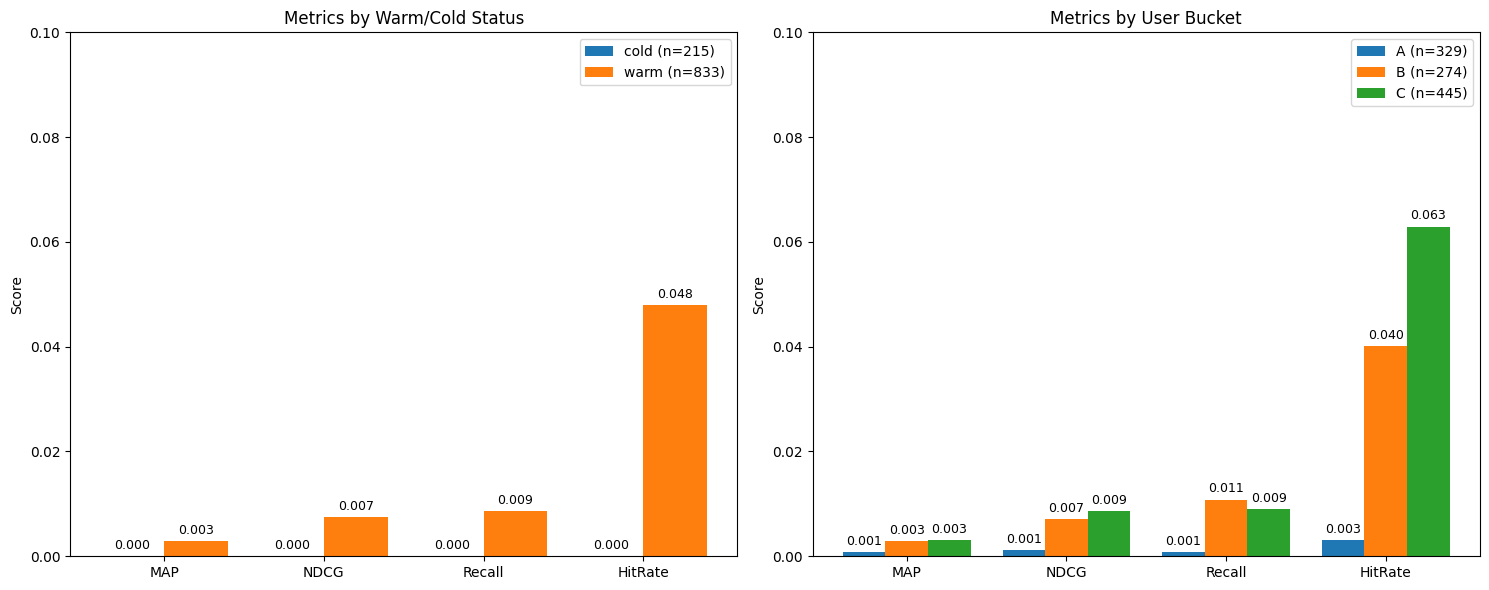

INFO:__main__:  Evaluating season: winter_2019_2020...
INFO:__main__:    Ground truth window: 2019-12-23 to 2020-03-23
INFO:__main__:Split: train rows=20510643, test rows=11277681
INFO:__main__:    Building positive labels from test set...
INFO:__main__:    Computing metrics at K=12 for winter_2019_2020...
INFO:__main__:    winter_2019_2020 metrics: {'MAP': 0.0016986886180459133, 'NDCG': 0.0037924761701478727, 'Recall': 0.005741456087937964, 'HitRate': 0.022388059701492536, 'user_count': 938}
INFO:__main__:Plotting metric breakdown...


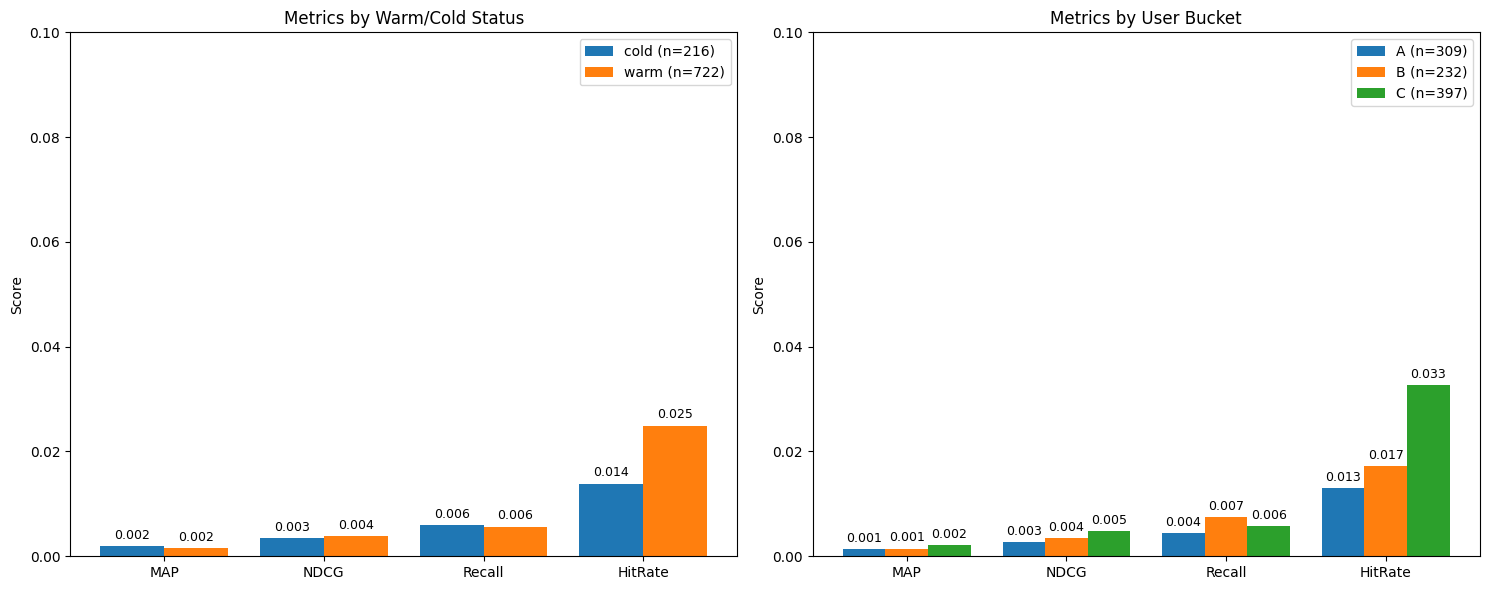

INFO:__main__:  Evaluating season: spring_2020...
INFO:__main__:    Ground truth window: 2020-03-23 to 2020-06-23
INFO:__main__:Split: train rows=23637368, test rows=8150956
INFO:__main__:    Building positive labels from test set...
INFO:__main__:    Computing metrics at K=12 for spring_2020...
INFO:__main__:    spring_2020 metrics: {'MAP': 0.0024819372386166274, 'NDCG': 0.005077773690917755, 'Recall': 0.004475693006788651, 'HitRate': 0.025763358778625955, 'user_count': 1048}
INFO:__main__:Plotting metric breakdown...


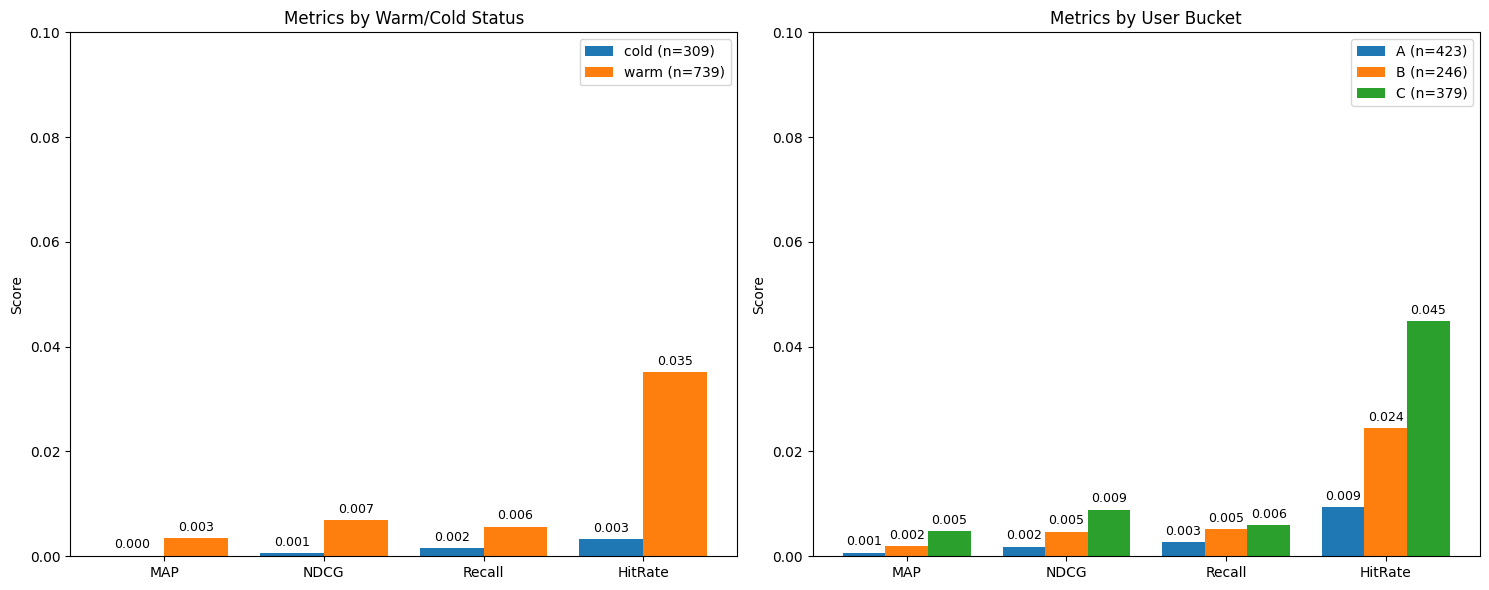

INFO:__main__:  Evaluating season: summer_2020...
INFO:__main__:    Ground truth window: 2020-06-23 to 2020-09-23
INFO:__main__:Split: train rows=27806866, test rows=3981458
INFO:__main__:    Building positive labels from test set...
INFO:__main__:    Computing metrics at K=12 for summer_2020...
INFO:__main__:    summer_2020 metrics: {'MAP': 0.0011242517708034948, 'NDCG': 0.0029160392379897525, 'Recall': 0.0034200663057287377, 'HitRate': 0.0195712954333644, 'user_count': 1073}
INFO:__main__:Plotting metric breakdown...


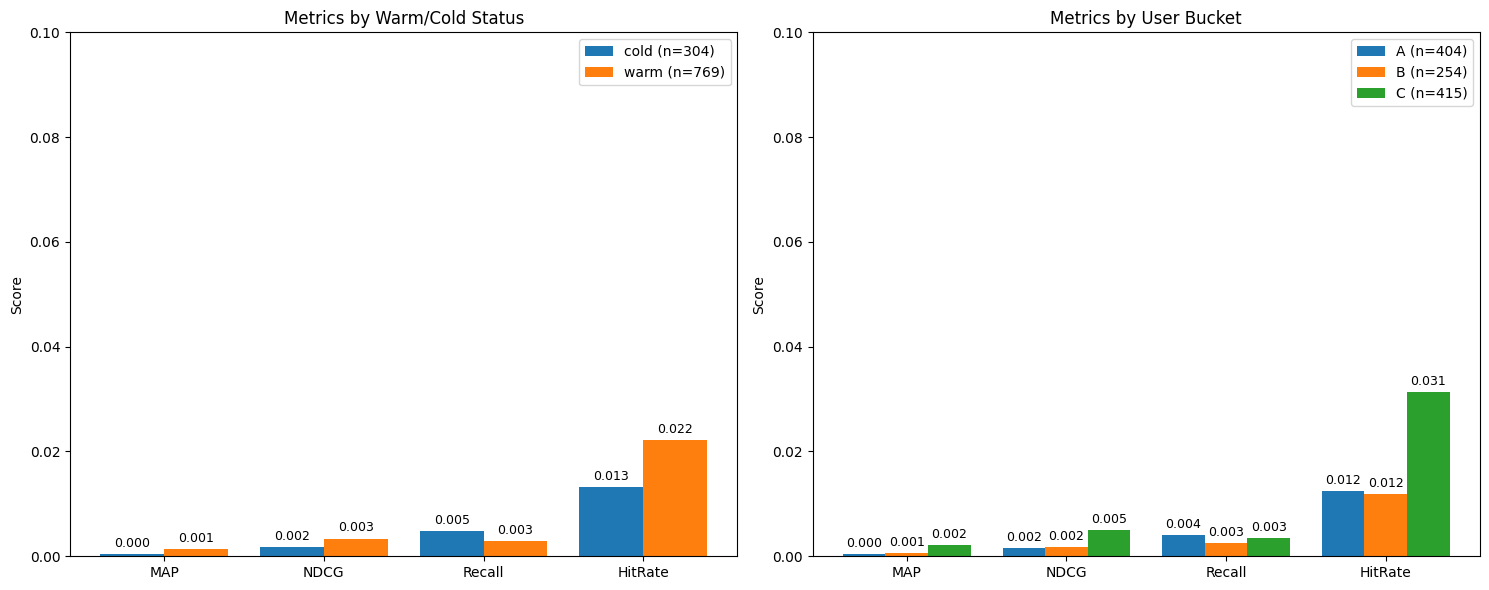

INFO:__main__:  Computing aggregate metrics across all seasons...
INFO:__main__:FINAL CROSS-SEASON METRICS: {'MAP': 0.001896059906034166, 'NDCG': 0.004426755789077572, 'Recall': 0.005108330245289646, 'HitRate': 0.026540053567080595, 'user_count': 4107}
INFO:__main__:Plotting metric breakdown...


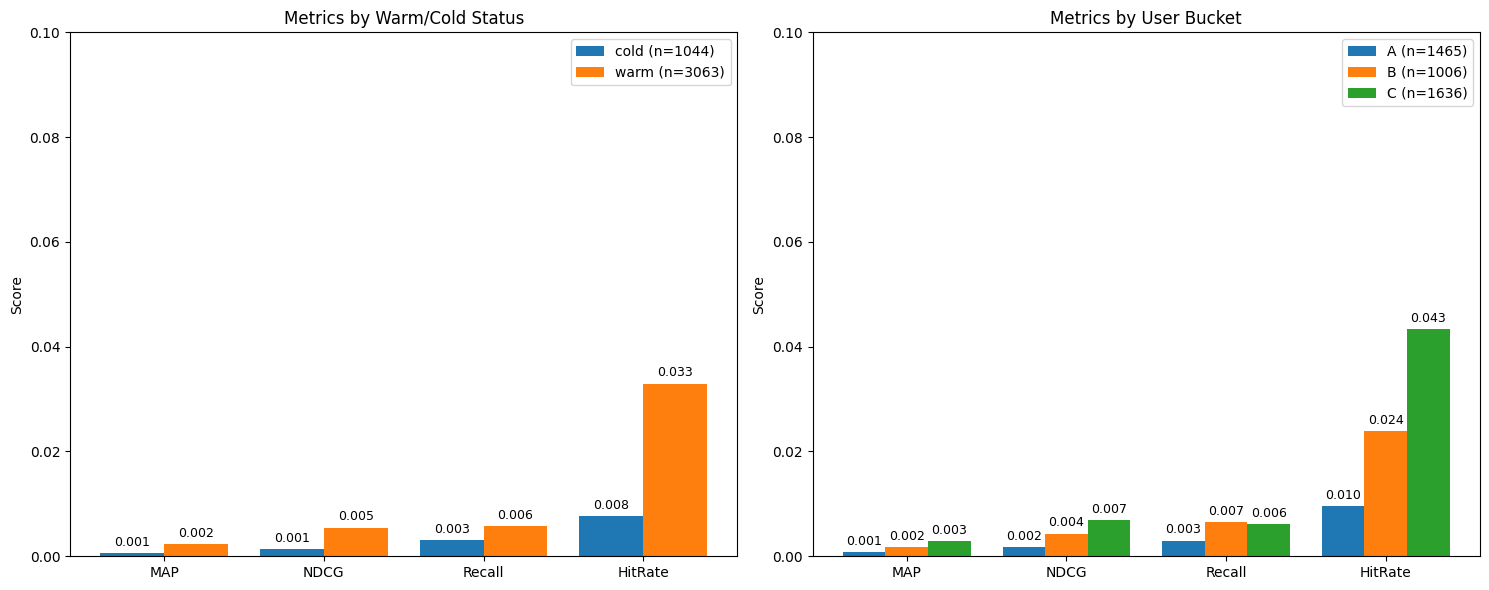

INFO:__main__:Pipeline finished in 6913.74 seconds


In [30]:
import sys
logging.basicConfig(level=logging.INFO, stream=sys.stdout, force=True)

pipeline_report = run_pipeline(
    df_transactions=df_transactions,
    df_users=df_customers,
    df_articles=df_articles,
    cutoff_date='2019-09-23',          # Train on data before 2019-09-23, test on 2019-09-23 onwards
    prediction_dates=prediction_dates_dict,      # Generate recommendations for specified seasonal dates
    n_train_users=12000,               # Subsample 12k active users for training
    n_test_users=2000,                 # Evaluate on 2k random test users
    balance_threshold=0.7,             # Require seasonal balance score >= 0.7
    low_percentile=50,                         # Users with ≤ low_cut transactions → bucket A (low activity)
    high_percentile=80,                       # Users with ≥ high_cut transactions → bucket C (high activity)
    top_k=12,                          # Recommend top‑12 items per user to compare against competition standards
    random_seed=25
)

# PIPELINE REPORT

In [31]:
import numpy as np

def compute_entropy(values):
    """Normalized entropy of a set of non‑negative values."""
    arr = np.array(values, dtype=float)
    if arr.sum() == 0:
        return 0.0
    probs = arr / arr.sum()
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log(probs))
    return entropy / np.log(len(arr))

def find_outliers(series, season_names):
    """Return list of season names that are outliers using the 1.5×IQR rule."""
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = []
    for i, val in enumerate(series):
        if val < lower or val > upper:
            outliers.append(season_names[i])
    return outliers

def print_pipeline_report(report):
    meta     = report.get('metadata', {})
    sub      = report.get('subsample_report', {})
    training = report.get('training_results', {})
    seasonal = report.get('seasonal_metrics', {})

    W = 70
    def section(title):
        print(f"\n{'=' * W}")
        print(f"  {title}")
        print(f"{'=' * W}")
    def row(label, value, indent=2):
        dots = '.' * (40 - len(label) - indent)
        print(f"{' ' * indent}{label} {dots} {value}")

    # --- (Existing sections: OVERVIEW, DATA SPLIT, SUBSAMPLING, TRAINING, TEST INFERENCE) ---
    # ... keep the same code for those sections as in your original function ...

    # --- UPDATED EVALUATION SECTION ---
    section("STEP 5 — EVALUATION METRICS  (K = " + str(meta.get('top_k', '?')) + ")")
    k = meta.get('top_k', '?')
    season_names = [sn.replace('_', ' ').upper() for sn in seasonal.keys() if sn != 'aggregate_overall']
    metrics = ['MAP', 'NDCG', 'Recall', 'HitRate']

    # Collect per-season overall values
    season_vals = {metric: [] for metric in metrics}
    for season_name in seasonal:
        if season_name == 'aggregate_overall':
            continue
        m = seasonal[season_name]
        overall = m.get('overall', {})
        for metric in metrics:
            season_vals[metric].append(overall.get(metric, 0.0))

    # Print per-season details
    for season_name, m in seasonal.items():
        # Override the displayed user count for the aggregate entry
        overall = m.get('overall', {})   # ← add this line
        if season_name == 'aggregate_overall':
            n_seasons = len([s for s in seasonal if s != 'aggregate_overall'])
            displayed_n = meta.get('n_test_users', 2000) * n_seasons
        else:
            displayed_n = m.get('overall', {}).get('user_count', 0)

        print(f"\n  [{season_name.replace('_', ' ').upper()}]")
        print(f"  Overall  (n={displayed_n:,} users with purchases in test period)")

        for metric in metrics:
            row(f"    {metric}@{k}", f"{overall.get(metric, 0):.4f}", indent=4)

        print(f"\n  Warm vs cold-start breakdown:")
        bwc = m.get('by_warm_cold', {})
        for seg in ['warm', 'cold']:
            d = bwc.get(seg, {})
            n = d.get('user_count', 0)
            print(f"    {seg.capitalize()} (n={n:,})")
            for metric in metrics:
                row(f"      {metric}@{k}", f"{d.get(metric, 0):.4f}", indent=6)

        print(f"\n  Activity bucket breakdown:")
        bb = m.get('by_bucket', {})
        for bucket in ['A', 'B', 'C']:
            d = bb.get(bucket, {})
            n = d.get('user_count', 0)
            print(f"    Bucket {bucket} (n={n:,})")
            for metric in metrics:
                row(f"      {metric}@{k}", f"{d.get(metric, 0):.4f}", indent=6)

    # --- NEW: Cross‑Season Consistency Analysis ---
    if len(season_names) >= 2:
        print(f"\n  {'─' * 50}")
        print("  CROSS‑SEASON CONSISTENCY ANALYSIS")
        print(f"  (based on overall metrics across {len(season_names)} seasonal windows)")
        print(f"  {'─' * 50}\n")

        for metric in metrics:
            vals = np.array(season_vals[metric])
            mean_val = np.mean(vals)
            std_val = np.std(vals)
            min_val = np.min(vals)
            max_val = np.max(vals)
            entropy = compute_entropy(vals)
            outliers = find_outliers(vals, season_names)

            print(f"  {metric}@{k}:")
            row("Mean", f"{mean_val:.4f}", indent=4)
            row("Std", f"{std_val:.4f}", indent=4)
            row("Min / Max", f"{min_val:.4f} / {max_val:.4f}", indent=4)
            row("Normalized entropy", f"{entropy:.4f} (0=identical, 1=uniform)", indent=4)
            if outliers:
                row("Outlier season(s)", ", ".join(outliers), indent=4)
            else:
                row("Outlier season(s)", "None", indent=4)
            # Identify best and worst season
            best_idx = np.argmax(vals)
            worst_idx = np.argmin(vals)
            row("Best season", f"{season_names[best_idx]} ({vals[best_idx]:.4f})", indent=4)
            row("Worst season", f"{season_names[worst_idx]} ({vals[worst_idx]:.4f})", indent=4)
            print()

    print(f"\n{'=' * W}\n")

print_pipeline_report(pipeline_report)


  STEP 5 — EVALUATION METRICS  (K = 12)

  [AUTUMN 2019]
  Overall  (n=1,048 users with purchases in test period)
        MAP@12 .......................... 0.0023
        NDCG@12 ......................... 0.0059
        Recall@12 ....................... 0.0069
        HitRate@12 ...................... 0.0382

  Warm vs cold-start breakdown:
    Warm (n=833)
            MAP@12 ...................... 0.0029
            NDCG@12 ..................... 0.0074
            Recall@12 ................... 0.0087
            HitRate@12 .................. 0.0480
    Cold (n=215)
            MAP@12 ...................... 0.0000
            NDCG@12 ..................... 0.0000
            Recall@12 ................... 0.0000
            HitRate@12 .................. 0.0000

  Activity bucket breakdown:
    Bucket A (n=329)
            MAP@12 ...................... 0.0008
            NDCG@12 ..................... 0.0012
            Recall@12 ................... 0.0008
            HitRate@12 .........